# Homework 1 - data validation & cleaning (deadline 3. 11. 2024, 23:59)

In short, the main task is to clean The Metropolitan Museum of Art Open Access dataset.
  
> The instructions are not given in detail: It is up to you to come up with ideas on how to fulfill the particular tasks as best as possible!

However, we **strongly recommend and require** the following:
* Follow the assignment step by step. Number each step.
* Most steps contain the number of features that should be treated. You can preprocess more features. However, it does not mean the teacher will give you more points. Focus on quality, not quantity.
* Properly comment on all your steps. Use Markdown cells and visualizations. Comments are evaluated for 2 points of the total, together with the final presentation of the solution. However, it is not desirable to write novels! 
* This task is timewise and computationally intensive. Do not leave it to the last minute.
* Hand in a notebook that has already been run (i.e., do not delete outputs before handing in).

## What are you supposed to do:

  1. Download the dataset MetObjects.csv from the repository https://github.com/metmuseum/openaccess/.
  1. Check consistency (i.e., that the same things are represented in the same way) of at least **three features** where you expect problems (including the "Object Name" feature). You can propose how to clean the selected features. However, **do not apply cleaning** (in your interest) 🙂 _(1.5 points)_
  1. Select at least **two features** (i.e., one couple) where you expect integrity problems (describe your choice) and check the integrity of those features. By integrity, we mean correct logical relations between features (e.g., female names for females only). _(2 points)_
  1. Convert at least **five features** to a proper data type. Choose at least one numeric, one categorical (i.e., ordinal or nominal), and one datetime. _(1.5 points)_
  1. Find some outliers and describe your method. _(3 points, depends on creativity)_
  1. Detect missing data in at least **three features**, convert them to a proper representation (if they are already not), and impute missing values in at least **one feature** using some imputation method (i.e., imputation by mean or median is too trivial to obtain any points). _(2 + 3 points, depends on creativity)_
  1. Focus more precisely on cleaning the "Medium" feature. As if you were to use it in the KNN classification algorithm later. _(3 points)_
  1. Focus on the extraction of the physical dimensions of each item (width, depth, and height in centimeters) from the "Dimensions" feature. _(2 points)_
  
All your steps, your choices of methods, and the following code **must be commented on!** For text comments (discussion, etc., not code comments), use **Markdown cells**. Comments are evaluated for 2 points together with the final presentation of the solution. 

**If you do all this properly, you will obtain 20 points.**

## Comments

  * Please follow the technical instructions from https://courses.fit.cvut.cz/NI-PDD/homeworks/index.html.
  * Methods that are more complex and were not shown during the tutorials are considered more creative and should be described in detail.
  * English is not compulsory.

In [39]:
import re
import string

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from IPython.display import display
from datetime import datetime
from spellchecker import SpellChecker
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
import pickle

dataset_path = 'MetObjects.txt'
rd_seed = 42

ImportError: cannot import name 'SparseDtype' from 'pandas.api.types' (/home/bardanik/miniforge3/envs/ni-pdd/lib/python3.11/site-packages/pandas/api/types/__init__.py)

# 0. Dataset Exploration

## Columns Description

On [API pages](https://metmuseum.github.io/) we can find some information about the columns we have here.

In [7]:
df = pd.read_csv(dataset_path, low_memory=False)
df.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


Documented columns:

| Field                   | Type | Notes | Example(s) |
|-------------------------|-|-|-|
| Is Highlight            | boolean | When "true" indicates a popular and important artwork in the collection | Vincent van Gogh's "Wheat Field with Cypresses" |
| Is Timeline Work        | boolean | Whether the object is on the Timeline of Art History website | true |
| Is Public Domain        | boolean | When "true" indicates an artwork in the Public Domain | Vincent van Gogh's "Wheat Field with Cypresses" |
| Object ID               | int | Identifying number for each artwork (unique, can be used as key field) | 437133 |
| Gallery Number          | string | Gallery number, where available | "131" |
| Department              | string | Indicates The Met's curatorial department responsible for the artwork | "Egyptian Art" |
| Accession Year          | string | Year the artwork was acquired. | "1921" |
| Object Name             | string | Describes the physical type of the object | "Dress", "Painting", "Photograph", or "Vase" |
| Title                   | string | Title, identifying phrase, or name given to a work of art | "Wheat Field with Cypresses" |
| Culture                 | string | Information about the culture, or people from which an object was created | "Afghan", "British", "North African" |
| Period                  | string | Time or time period when an object was created | "Ming dynasty (1368-1644)", "Middle Bronze Age" |
| Dynasty                 | string | Dynasty (a succession of rulers of the same line or family) under which an object was created | "Kingdom of Benin", "Dynasty 12" |
| Reign                   | string | Reign of a monarch or ruler under which an object was created | "Amenhotep III", "Darius I", "Louis XVI" |
| Portfolio               | string | A set of works created as a group or published as a series. | "Birds of America", "The Hudson River Portfolio", "Speculum Romanae Magnificentiae" |
| Artist Role             | string | Role of the artist related to the type of artwork or object that was created | "Artist for Painting", "Designer for Dress" |
| Artist Prefix           | string | Describes the extent of creation or describes an attribution qualifier to the information given in the artistRole field | "In the Style of", "Possibly by", "Written in French by" |
| Artist Display Name     | string | Artist name in the correct order for display | "Vincent van Gogh" |
| Artist Display Bio      | string | Nationality and life dates of an artist, also includes birth and death city when known. | "Dutch, Zundert 1853–1890 Auvers-sur-Oise" |
| Artist Suffix           | string | Used to record complex information that qualifies the role of a constituent, e.g. extent of participation by the Constituent (verso only, and followers) | "verso only" |
| Artist Alpha Sort       | string | Used to sort artist names alphabetically. Last Name, First Name, Middle Name, Suffix, and Honorific fields, in that order. | "Gogh, Vincent van" |
| Artist Nationality      | string | National, geopolitical, cultural, or ethnic origins or affiliation of the creator or institution that made the artwork | "Spanish"; "Dutch"; "French, born Romania" |
| Artist Begin Date       | string | Year the artist was born | "1840" |
| Artist End Date         | string | Year the artist died | "1926" |
| Artist Gender           | string | Gender of the artist (currently contains female designations only) | "female" |
| Artist ULAN_URL         | string | ULAN URL for the artist | "https://vocab.getty.edu/page/ulan/500003169" |
| Artist Wikidata_URL     | string | Wikidata URL for the artist | "https://www.wikidata.org/wiki/Q694774" |
| Object Date             | string | Year, a span of years, or a phrase that describes the specific or approximate date when an artwork was designed or created | "1865–67", "19th century", "ca. 1796" |
| Object Begin Date       | int | Machine readable date indicating the year the artwork was started to be created | 1867, 1100, -900 |
| Object End Date         | int | Machine readable date indicating the year the artwork was completed (may be the same year or different year than the objectBeginDate) | 1888, 1100, -850 |
| Medium                  | string | Refers to the materials that were used to create the artwork | "Oil on canvas", "Watercolor", "Gold" |
| Dimensions              | string | Size of the artwork or object | "16 x 20 in. (40.6 x 50.8 cm)" |
| Credit Line             | string | Text acknowledging the source or origin of the artwork and the year the object was acquired by the museum. | "Robert Lehman Collection, 1975" |
| Geography Type          | string | Qualifying information that describes the relationship of the place catalogued in the geography fields to the object that is being catalogued | "Made in", "From", "Attributed to" |
| City                    | string | City where the artwork was created | "New York", "Paris", "Tokyo" |
| State                   | string | State or province where the artwork was created, may sometimes overlap with County | "Alamance", "Derbyshire", "Brooklyn" |
| County                  | string | County where the artwork was created, may sometimes overlap with State | "Orange County", "Staffordshire", "Brooklyn" |
| Country                 | string | Country where the artwork was created or found | "China", "France", "India" |
| Region                  | string | Geographic location more specific than country, but more specific than subregion, where the artwork was created or found (frequently null) | "Bohemia", "Midwest", "Southern" |
| Subregion               | string | Geographic location more specific than Region, but less specific than Locale, where the artwork was created or found (frequently null) | "Malqata", "Deir el-Bahri", "Valley of the Kings" |
| Locale                  | string | Geographic location more specific than subregion, but more specific than locus, where the artwork was found (frequently null) | "Tomb of Perneb", "Temple of Hatshepsut", "Palace of Ramesses II" |
| Locus                   | string | Geographic location that is less specific than locale, but more specific than excavation, where the artwork was found (frequently null) | "1st chamber W. wall"; "Burial C 2, In coffin"; "Pit 477" |
| Excavation              | string | The name of an excavation. The excavation field usually includes dates of excavation. | "MMA excavations, 1923–24"; "Khashaba excavations, 1910–11"; "Carnarvon excavations, 1912" |
| River                   | string | River is a natural watercourse, usually freshwater, flowing toward an ocean, a lake, a sea or another river related to the origins of an artwork (frequently null) | "Mississippi River", "Nile River", "River Thames" |
| Classification          | string | General term describing the artwork type. | "Basketry", "Ceramics", "Paintings" |
| Rights And Reproduction | string | Credit line for artworks still under copyright. | "© 2018 Estate of Pablo Picasso / Artists Rights Society (ARS), New York" |
| Link Resource           | string | URL to object's page on metmuseum.org | "https://www.metmuseum.org/art/collection/search/547802" |
| Object Wikidata_URL     | string | Wikidata URL for the object | "https://www.wikidata.org/wiki/Q432253" |
| Metadata Date           | datetime | Date metadata was last updated | 2018-10-17T10:24:43.197Z |
| Repository              | string |  | "Metropolitan Museum of Art, New York, NY" |
| Tags                    | array | An array of subject keyword tags associated with the object and their respective AAT URL | [{"term": "Abstraction","AAT_URL": "http://vocab.getty.edu/page/aat/300056508","Wikidata_URL": "https://www.wikidata.org/wiki/Q162150"}] |




**Constituend ID** meaning can be deduced from the **constituents** attribute in API documentation.

| Field                   | Type | Notes | Example(s) |
|-------------------------|-|-|-|
| constituents            | array | An array containing the constituents associated with an object, with the constituent's role, name, ULAN URL, Wikidata URL, and gender, when available (currently contains female designations only). | [{"constituentID": 161708,"role": "Artist","name": "Louise Bourgeois","constituentULAN_URL": "http://vocab.getty.edu/page/ulan/500057350","constituentWikidata_URL": "https://www.wikidata.org/wiki/Q159409","gender": "Female"}] |

## Splitting Dataset into Objects and Artists

If we look at artists columns, we will see, that they are concatenated lists, joined together by '|' (or in some cases without - we look at you, **Constituend ID**)

i.e. object 444:

In [8]:
artist_columns = ['Constituent ID', 'Artist Role', 'Artist Prefix', 'Artist Display Name', 'Artist Display Bio',
                  'Artist Suffix',
                  'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date', 'Artist End Date', 'Artist Gender',
                  'Artist ULAN URL', 'Artist Wikidata URL']

df[df['Object ID'] == 444][artist_columns]

,Constituent ID,Artist Role,Artist Prefix,Artist Display Name,Artist Display Bio,Artist Suffix,Artist Alpha Sort,Artist Nationality,Artist Begin Date,Artist End Date,Artist Gender,Artist ULAN URL,Artist Wikidata URL
387,1192174616222311149447,Maker|Maker|Decorator|Decorator|Decorator,Possibly by|Cornice attributed to|Painting att...,Thomas Seymour|John Doggett|John Ritto Pennima...,"1771–1848|1780–1857|American, Milford, Massach...",| | | |,"Seymour, Thomas|Doggett, John|Penniman, John R...",American|American|American|American|American,1771 |1780 |1782 |1757 |17...,1848 |1857 |1841 |1811 |18...,||||,http://vocab.getty.edu/page/ulan/500023428|htt...,https://www.wikidata.org/wiki/Q61764333|https:...


The biggest problem here is the **Constituent ID**, because IDs of artist are concatenated there without any delimiter (to overcome this problem, we need to find rows where there is only one artist, remember his ID, make a table from that, and iteratively deduce IDss of other artists by removing known IDs from the joined IDs).

We will do nothing with that, we will just copy Constituent ID and if there is only one artist in constituents list, we will mark the Constituent ID as his/her own ID in separate column (**Artist ID**).

Also, we will create two helper columns:
 - order of the artist in the constituent list (Constituent ID List Order), so if someone will work later on this dataset, it will be clear, that in the same list artists are ordered, and joint Constituent ID can be parsed to find out IDs of other artists.
  - Constituents Number - number of artists in that worked on the object.


In [10]:
# Object ID has no missing values and no duplicates, we will use it to bind tables (using join by Object ID)
df_artists = pd.DataFrame(df['Object ID'])

# first, split entries by '|', assign orders, and create Artist ID column
for column in artist_columns:
    if column == 'Constituent ID':  # this column cannot be splitted
        df_artists[column] = df[column]
        continue
    artists_df_column_name = column.replace('Artist ', '').strip()
    df_artists[artists_df_column_name] = df[column].str.split('|')

df_artists['Constituents Number'] = df_artists['Display Name'].apply(
    lambda x: len(x) if isinstance(x, list) else np.NaN
).astype(pd.Int64Dtype())

df_artists['Constituent Order'] = df_artists['Constituents Number'].apply(
    lambda x: np.NaN if pd.isna(x) else list(range(int(x))))

df_artists['Artist ID'] = df_artists.apply(
    lambda row: [row['Constituent ID']] if isinstance(row['Constituent Order'], list) and len(
        row['Constituent Order']) == 1 else np.NaN, axis=1)

df_artists.head(5)

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
0,1,16429,[Maker],[ ],[James Barton Longacre],"[American, Delaware County, Pennsylvania 1794–...",[ ],"[Longacre, James Barton]",[American],[1794 ],[1869 ],NaN,[http://vocab.getty.edu/page/ulan/500011409],[https://www.wikidata.org/wiki/Q3806459],1,[0],[16429]
1,2,107,[Maker],[ ],[Christian Gobrecht],[1785–1844],[ ],"[Gobrecht, Christian]",[American],[1785 ],[1844 ],NaN,[http://vocab.getty.edu/page/ulan/500077295],[https://www.wikidata.org/wiki/Q5109648],1,[0],[107]
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN


In [11]:
columns_to_explode = [column_name.replace('Artist ', '').strip() for column_name in artist_columns] + ['Artist ID',
                                                                                                       'Constituent Order']
columns_to_explode.remove('Constituent ID')

To use **explode** function to convert to a long format, we need to have same elements number in the lists. But some values are `NaN`. Thus, we will convert those `NaN` values into a lists. If the constituent number is 3, then transformation will be as follows: `NaN` -> `[NaN, NaN, NaN]`. This is computationally not optimal, but in this context it suffices. Better approach would be to explode each column and merge them be compound indexes (Object ID and Artist Order).

In [14]:
def nans_to_list(row: pd.DataFrame) -> pd.DataFrame:
    constituents_number = row['Constituents Number']
    if pd.isna(constituents_number):
        return row
    for column in columns_to_explode:
        if isinstance(row[column], list) or not pd.isna(row[column]):
            continue
        row[column] = [np.NaN] * constituents_number
    return row


df_artists = df_artists.apply(nans_to_list, axis=1)

In [15]:
df_artists.head()

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
0,1,16429,[Maker],[ ],[James Barton Longacre],"[American, Delaware County, Pennsylvania 1794–...",[ ],"[Longacre, James Barton]",[American],[1794 ],[1869 ],[nan],[http://vocab.getty.edu/page/ulan/500011409],[https://www.wikidata.org/wiki/Q3806459],1,[0],[16429]
1,2,107,[Maker],[ ],[Christian Gobrecht],[1785–1844],[ ],"[Gobrecht, Christian]",[American],[1785 ],[1844 ],[nan],[http://vocab.getty.edu/page/ulan/500077295],[https://www.wikidata.org/wiki/Q5109648],1,[0],[107]
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN


In [16]:
df_artists = df_artists.explode(column=columns_to_explode)
df_artists.to_csv('artists.csv', index=False)
df_artists.head()

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
0,1,16429,Maker,,James Barton Longacre,"American, Delaware County, Pennsylvania 1794–1...",,"Longacre, James Barton",American,1794,1869,NaN,http://vocab.getty.edu/page/ulan/500011409,https://www.wikidata.org/wiki/Q3806459,1,0,16429
1,2,107,Maker,,Christian Gobrecht,1785–1844,,"Gobrecht, Christian",American,1785,1844,NaN,http://vocab.getty.edu/page/ulan/500077295,https://www.wikidata.org/wiki/Q5109648,1,0,107
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN


Now we can remove artists' columns from the objects, and work more efficiently with two separate datasets. We always can join them by Object ID, if needed.

In [17]:
df_objects = df.drop(columns=artist_columns)
df_objects.to_csv('objects.csv', index=False)
df_objects.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [18]:
# clean up
del df

In [2]:
# read both datasets if needed
df_artists = pd.read_csv('artists.csv', low_memory=False)
df_objects = pd.read_csv('objects.csv', low_memory=False)

# 1. Consistency

Consistency is about to check if same things are represented in the same way. Thus, representation is consistent across all the dataset.

There are different ways to examine consistency, depending on the feature we examine.

We will define helper functions here to check consistency of features that will follow.

In [3]:
def unique_difference(transformation, df_orig):
    """
    Function to find all unique domain values of transformation function.

    It is used to find all the original values, that has same representation after applying transformation.
    For example, if transformation is lowercase, then 'Coin' and 'coin' will transform to 'coin'.
    This function helps to visualize such occurrences, so we can check consistency, i.e. if all strigns are lowercased.
    :param transformation: function which transform values.
    :param df_orig: dataframe to examine.
    :return: key-value pairs, where key is the range, and value is domain of transformation function.
    """
    before_nuniques = df_orig.nunique()
    df_transformed = df_orig.apply(func=transformation)
    after_nuniques = df_transformed.nunique()
    diff = before_nuniques - after_nuniques

    # print some statistics
    print(f'Number of unique values before {transformation.__name__}: {before_nuniques}')
    print(f'Number of unique values after {transformation.__name__}: {after_nuniques}')
    print(f'Difference: {diff}')
    print(
        f'Ratio of values with different cases to all uniques before {transformation.__name__}: {diff / before_nuniques:.2f}')

    orig_uniques = df_orig.unique()

    transformation_mappings = dict()
    for original_value in orig_uniques:
        transformed = transformation(original_value)
        if transformed not in transformation_mappings:
            transformation_mappings[transformed] = set()
        transformation_mappings[transformed].add(original_value)

    # filter from key-value pairs, where only one unique value from domain is mapped to one range value.
    filtered_from_singletons = {transformed: originals for transformed, originals in transformation_mappings.items() if
                                len(originals) > 1}
    return filtered_from_singletons


def display_top_n_dict(dictionary, n: int = 5):
    """Helper function to display unique differences."""
    top_n_examples_list = [item for idx, item in enumerate(dictionary.items()) if idx < n]
    print(f'Top {n} examples:')
    display(top_n_examples_list)

Here we define some transformation function that we will use:

In [4]:
def lowercase(value: str | None) -> str | None:
    if isinstance(value, str):
        return value.lower()
    return value


def whitespaces_reduction(value: str | None) -> str | None:
    if isinstance(value, str):
        return re.sub(r'\s+', ' ', value.strip())
    return value


def special_characters_reduction(value: str, pattern=r'[^\w\s]') -> str:
    if isinstance(value, str):
        return re.sub(pattern, '', value)
    return value

## Object Name

| Field                   | Type | Notes | Example(s) |
|-------------------------|-|-|-|
| Object Name             | string | Describes the physical type of the object | "Dress", "Painting", "Photograph", or "Vase" |

We will examine following inconsistencies:
- case consistency - lowercase and uppercase
- leading, intermediate, trailing whitespaces
- special characters and punctuation

In [6]:
ser_obj_nm = df_objects['Object Name']

In [5]:
def introduce_data(data: pd.DataFrame | pd.Series, column=None):
    if column:
        selected_data = data[column]
    else:
        selected_data = data
    display(selected_data.describe())
    display(selected_data.info())
    if isinstance(selected_data, pd.Series):
        nans_number = selected_data.isna().sum()
        print(f'Number of NaN values: {nans_number} ({100 * nans_number / len(selected_data):.2f}%)')

In [16]:
introduce_data(ser_obj_nm)

count     482690
unique     28631
top        Print
freq      102986
Name: Object Name, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Object Name
Non-Null Count   Dtype 
--------------   ----- 
482690 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 2266 (0.47%)


In [10]:
# to apply transformation functions we need to get rid of NaN values
ser_obj_nm_dropna = ser_obj_nm.dropna()

Case consistency check:

In [11]:
display_top_n_dict(unique_difference(lowercase, ser_obj_nm_dropna), 5)

Number of unique values before lowercase: 28631
Number of unique values after lowercase: 27760
Difference: 871
Ratio of values with different cases to all uniques before lowercase: 0.03
Top 5 examples:


[('coin', {'Coin', 'coin'}),
 ('vase', {'Vase', 'vase'}),
 ('side chair', {'Side Chair', 'Side chair'}),
 ('figure', {'FIgure', 'Figure'}),
 ('statuette', {'Statuette', 'statuette'})]

3% of unique values differs only in case from the rest.


Whitespaces check:

In [12]:
display_top_n_dict(unique_difference(whitespaces_reduction, ser_obj_nm_dropna))

Number of unique values before whitespaces_reduction: 28631
Number of unique values after whitespaces_reduction: 28293
Difference: 338
Ratio of values with different cases to all uniques before whitespaces_reduction: 0.01
Top 5 examples:


[('Bust', {'Bust', 'Bust '}),
 ('Vase', {'Vase', 'Vase\r\n', 'Vase ', 'Vase \r\n'}),
 ('Figure', {'Figure', 'Figure\r\n', 'Figure ', 'Figure \r\n'}),
 ('Andiron', {'Andiron', 'Andiron '}),
 ('Statuette', {'Statuette', 'Statuette '})]

Only 1% of values have inconsistency with whitespaces.

Special characters check:


In [13]:
print(f'Considered special characters: {string.punctuation}')

Considered special characters: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [14]:
display_top_n_dict(unique_difference(special_characters_reduction, ser_obj_nm_dropna), 5)

Number of unique values before special_characters_reduction: 28631
Number of unique values after special_characters_reduction: 28311
Difference: 320
Ratio of values with different cases to all uniques before special_characters_reduction: 0.01
Top 5 examples:


[('Teapot', {'"Tea-pot"', 'Teapot'}),
 ('Dish', {'Dish', 'Dish(?)'}),
 ('Curtain tieback', {'Curtain tie-back', 'Curtain tieback'}),
 ('Plate', {'Plate', 'Plate?'}),
 ('Gateleg table', {'Gate-leg table', 'Gateleg table'})]

Only 1% of unique values have special characters inconsistency.

Another inconsistency is with using '?' in different formats, like with or without parenthesis. To consider examples like 'Plate' and 'Plate?' as inconsistent is a good question, because the question mark represents uncertainty, which may be important information.

Also, from example we see, that dashes '-' are also used inconsistently.

Let's apply all all the transformations and see the overall percentage of inconsistency among unique values:

In [15]:
display_top_n_dict(
    unique_difference(lambda x: special_characters_reduction(whitespaces_reduction(lowercase(x))), ser_obj_nm_dropna),
    5)

Number of unique values before <lambda>: 28631
Number of unique values after <lambda>: 27110
Difference: 1521
Ratio of values with different cases to all uniques before <lambda>: 0.05
Top 5 examples:


[('coin', {'Coin', 'coin'}),
 ('bust', {'Bust', 'Bust '}),
 ('vase', {'Vase', 'Vase\r\n', 'Vase ', 'Vase \r\n', 'vase'}),
 ('side chair', {'Side Chair', 'Side chair', 'Side chair '}),
 ('figure',
  {'FIgure', 'FIgure\r\n', 'Figure', 'Figure\r\n', 'Figure ', 'Figure \r\n'})]

5% of unique values are inconsistent using all of our 3 transformations. Of course, there may be other inconsistencies:
- misspells.
- different forms of a word, i.e. singular vs plural forms.

But those 5% are among unique values. Let's see how many values will be transformed to more consistent representation

In [16]:
df_obj_nm = pd.DataFrame(ser_obj_nm_dropna)
df_obj_nm['Object Name Lowercased'] = ser_obj_nm_dropna.apply(lambda x: lowercase(x))
df_obj_nm['Object Name W-S Reduction'] = ser_obj_nm_dropna.apply(
    lambda x: special_characters_reduction(whitespaces_reduction(x)))
df_obj_nm['Object Name Transformed'] = ser_obj_nm_dropna.apply(
    lambda x: special_characters_reduction(whitespaces_reduction(lowercase(x))))
for column, transformation in {'Object Name Lowercased': 'Lowercasing',
                               'Object Name W-S Reduction': 'Whitespace-Special Characters Reduction',
                               'Object Name Transformed': 'Lowercasing & Whitespace-Special Characters Reduction'}.items():
    df_diff = df_obj_nm[df_obj_nm['Object Name'] != df_obj_nm[column]]
    print(f'Transformation: {transformation}')
    print(f'Number of transformed (changed) values: {len(df_diff)}')
    print(f'{100 * len(df_diff) / len(df_obj_nm):.1f}% of values were changed.' + '\n')

Transformation: Lowercasing
Number of transformed (changed) values: 481117
99.7% of values were changed.

Transformation: Whitespace-Special Characters Reduction
Number of transformed (changed) values: 68495
14.2% of values were changed.

Transformation: Lowercasing & Whitespace-Special Characters Reduction
Number of transformed (changed) values: 481647
99.8% of values were changed.



We see how many values our transformations affected.

Now, let's examine top short and long values to find there some inconsistencies:

In [17]:
df_obj_nm = pd.DataFrame(ser_obj_nm_dropna)
df_obj_nm['Object Name Length'] = ser_obj_nm_dropna.apply(len)
df_obj_nm.drop_duplicates(subset='Object Name', keep='first', inplace=True)
df_obj_nm.nlargest(5, 'Object Name Length')

,Object Name,Object Name Length
20103,Double-barreled flintlock shotgun with exchang...,80
20388,Nineteen ornamental fittings from a horse harn...,80
25170,Ammunition belt (Kamr) Object Cards. S. martz...,80
25748,Blade and for a hatchet (Nata) and mounting fo...,80
29500,"Set of Pommel (Fuchigashira), Sword grip ornam...",80


In [18]:
df_obj_nm.nsmallest(5, 'Object Name Length')

,Object Name,Object Name Length
20273,Ax,2
147303,As,2
335145,Ūd,2
335195,Po,2
335197,Lo,2


Seemingly there is no inconsistencies - but let's check all unique object names with length of 2 and 3:

In [19]:
print(f'Object names with the length of 2: {list(df_obj_nm[df_obj_nm["Object Name Length"] == 2]["Object Name"])}')
print(f'Object names with the length of 3: {list(df_obj_nm[df_obj_nm["Object Name Length"] == 3]["Object Name"])}')

Object names with the length of 2: ['Ax', 'As', 'Ūd', 'Po', 'Lo', 'Bo', 'Gu', 'Ty', 'So', 'Em', 'Se', 'Yu']
Object names with the length of 3: ['Mug', 'Keg', 'Cup', 'Box', 'Jar', 'Cap', 'Pin', 'Urn', 'Jug', 'Die', 'Fan', 'Toy', 'Key', 'Lid', 'Map', 'Tyg', 'Pan', 'Pot', 'Rug', 'Hat', 'Ale', 'Bit', 'Bow', 'Axe', 'Saw', 'Gun', 'Mat', 'Qin', 'Dog', 'Bar', 'Obi', 'Cat', 'Bag', 'Tub', 'Tab', 'Fob', 'Boa', 'Aba', 'Kit', 'Wig', 'Bib', 'Fez', 'Alb', 'Pax', 'Pyx', 'Pen', 'Bed', 'Awl', 'Tie', 'Wax', 'Rod', 'Peg', 'Arm', 'Oon', 'Aes', 'Oar', 'Net', 'Rim', 'Top', 'jar', 'Gem', 'Rib', 'Bes', 'Kei', 'Sho', 'Fue', 'Hnè', 'Ozi', 'Koy', 'Tar', 'Saz', 'Zil', 'Baz', 'Nāy', 'Nay', 'Ney', 'Coc', 'Mai', 'Aje', 'Mam', 'Tār', 'Oko', 'Daf', 'Òzi', 'Gyo', 'Shō', 'Hun', 'Udu', 'Xun', 'Kin', 'Kou', 'Sut', 'Tro', 'Shu', 'Hoe', 'cat', 'Toe', 'Waj', 'Nai']


Everything looks valid, if we assume that some of the names may be from different languages.
Checking typos may be not a good idea, because we work with different languages, so it is possible that we can 'fix' correct word from other language.

Al last consistency check we will perform frequency analysis, which may help us to find:
- unexpected values (values that appear too frequently or vice versa)
- outliers
- duplicated or missing data (for example '??' instead of NaN)
- biases in data

In [20]:
ser_obj_nm_vc = ser_obj_nm.value_counts()
print('Top frequent elements:')
display(ser_obj_nm_vc.head(10))
print('Least frequent elements:')
display(ser_obj_nm_vc.tail(10))

Top frequent elements:


Object Name
Print             102986
Photograph         29451
Drawing            26018
Book               13397
Kylix fragment      8926
Piece               8621
Fragment            7213
Painting            6014
Negative            5928
Bowl                3633
Name: count, dtype: int64

Least frequent elements:


Object Name
Lekaina                                    1
Plate, Genucilia                           1
Two Panathenaic prize amphora fragments    1
Kantharos or rhyton                        1
Kylix fragments (26)                       1
Oinochoe in the form of a head of a man    1
Diskos                                     1
Neck-amphora, Tyrrhenian, fragmentary      1
Relief fragments, 12                       1
etching                                    1
Name: count, dtype: int64

- 'Print' is the most frequent item, but in this context it is OK.

Overall, there are no inconsistencies.

**Overall cleaning suggestions:**

To clean Object Name column we can apply our transformation, and figure out other similar transformations, like spellchecking, to make data even more consistent.

## Accession Year

In [56]:
ser_acsn_yr = df_objects['AccessionYear']
introduce_data(ser_acsn_yr)

count     481094
unique       180
top         1963
freq       41980
Name: AccessionYear, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: AccessionYear
Non-Null Count   Dtype 
--------------   ----- 
481094 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 3862 (0.80%)


There are only 180 unique values, we can look at them manually:

In [22]:
ser_acsn_yr.unique()

array(['1979', '1980', '1967', '1916', '1909', '1964', '1970', '1904',
       '1976', '1938', '1918', '1946', '1960', '1910', '1922', '1923',
       '1930', '1934', '1936', '1937', '1939', '1941', '1947', '1948',
       '1949', '1971', '1984', '1989', '1985', '1952', '1968', '1919',
       nan, '1978', '1972', '1924', '1983', '1950', '1925', '1926',
       '1931', '1932', '1951', '1953', '2006', '1969', '1975', '1981',
       '1986', '1959', '1944', '1982', '1945', '1888', '1911', '1957',
       '1943', '1935', '1917', '1973', '1940', '1913', '1962', '1914',
       '1966', '1954', '1920', '1933', '2014', '1928', '1901', '1958',
       '1965', '1883', '1902', '1987', '1974', '1977', '1915', '1942',
       '1912', '1927', '1896', '1892', '1877', '1906', '1955', '1961',
       '1994', '1907', '1929', '2018', '1921', '1908', '1963', '2010',
       '2000', '1988', '2021', '1956', '2012', '2013', '2002', '1999',
       '1894', '1897', '1993', '1893', '1992', '1996', '1898', '1899',
       '1

We see there striking inconsistency in date format:
- some of them are in more complete format, like '1968-12-12'.
- and others are just year, like '1961'.

Let's examine how many entires are ther with complete datetime:

In [118]:
def complete_dates_ratio(series: pd.Series) -> None:
    print("Complete dates statistics:\n")
    print(series.name, ':', sep='')
    dates_count = series.str.strip().str.match(r'\d{4}-\d{2}-\d{2}').sum()
    print('Number of entries with complete date: {}'.format(dates_count))
    print('Ratio of entries with complete date to non-NaN values: {:.2f}%'.format(
        100 * dates_count / len(series.dropna())))

In [209]:
complete_dates_ratio(ser_acsn_yr)

Complete dates statistics:

AccessionYear:
Number of entries with complete date: 40
Ratio of entries with complete date to non-NaN values: 0.01%



To clean this, there are two options:
- because there are only 40 entries (by 4 magnitudes less that total number of rows), we can just delete them.
- if we need to save this data, we can save complete dates in a new column **Accession Date**, and in **Accession Year** substitute dates with years.

Option to convert years to datetime type is not suitable: 
- by conversion, every year will get some month, day and time (01-01 00:00:00). But we don't know month, day and time when the object actually was accessed, we will just make up some data out of air, which may lead to problems later.
- we have mixed formats, unless we will extract year from the complete format and will ignore month and day.

## Gallery Number

In [177]:
ser_gal_num = df_objects['Gallery Number']
introduce_data(ser_gal_num)

count     49541
unique      379
top         774
freq       7547
Name: Gallery Number, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Gallery Number
Non-Null Count  Dtype 
--------------  ----- 
49541 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 435415 (89.78%)


- 89.78% of values are missing.
- there are only 378 unique values.
- type is object, implying that not all of the types are numerical.

Let's look at the data:

In [96]:
ser_gal_num.unique()[:80]

array([nan, '774', '706', '724', '741', '728', '719', '718', '729', '712',
       '516', '737', '738', '701', '734', '708', '722', '713', '730',
       '752', '736', '714', '740', '743', '725', '739', '745', '700',
       '704', '750', '512', '751', '717', '749', '733', '773', '710',
       '744', '726', '705', '732', '731', '723', '715', '508', '510',
       '747', '756', '720', '721', '766', '761', '762', '754', '372',
       '554', '707', '764', '768', '771', '760', '758', '759', '763',
       '681', '824', '769', '748', '753', '772', '755', 'in Great Hall',
       '767', '770', '765', '703', '809', '735', '727', '599'],
      dtype=object)

Some of the values are represented not as numbers, but as name of the gallery. Let's explore proportions of numbers, names and NaNs:

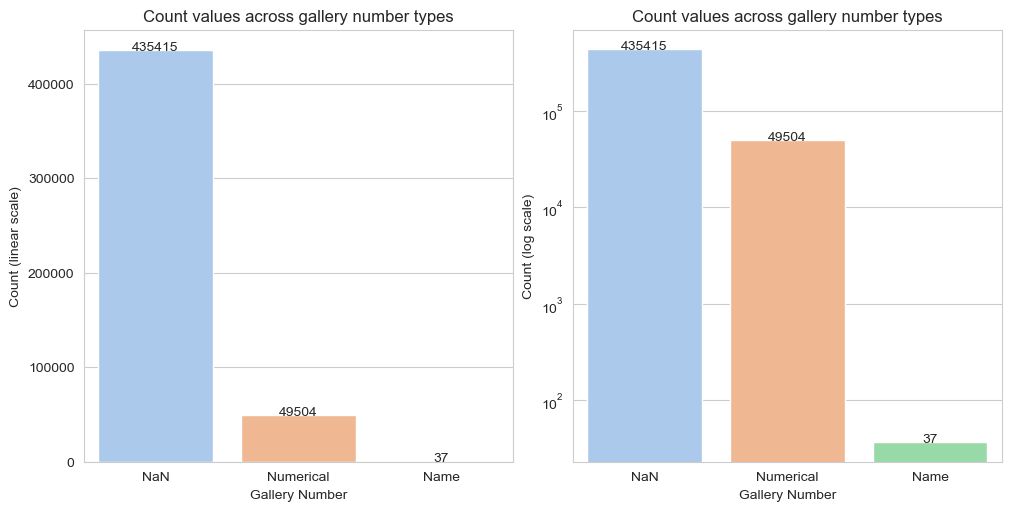

In [131]:
def categorize_gal_number(value):
    try:
        int(value)
        return 'Numerical'
    except ValueError:
        if pd.isna(value):
            return 'NaN'
        else:
            return 'Name'


ser_gal_num_categories_vc = ser_gal_num.apply(categorize_gal_number).value_counts()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), constrained_layout=True)

for ax, y_scale in zip(axes, ['linear', 'log']):
    sns.barplot(x=ser_gal_num_categories_vc.index, y=ser_gal_num_categories_vc.values,
                hue=ser_gal_num_categories_vc.index, palette='pastel', ax=ax)
    ax.set_title('Count values across gallery number types')
    ax.set_xlabel('Gallery Number')
    ax.set_ylabel('Count ({} scale)'.format(y_scale))
    ax.set_yscale(y_scale)

    for patch in ax.patches:
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width() / 2, height, s=int(height), ha='center')

plt.show()

There are only 37 gallery name values. Let's also look at them:

In [148]:
ser_gal_num_no_nans = ser_gal_num.dropna()
unique_gal_names = list(ser_gal_num_no_nans[ser_gal_num_no_nans.str.match(r'[a-zA-Z]+')].unique())
print('Unique gallery names: {}'.format(unique_gal_names))

Unique gallery names: ['in Great Hall', 'Petrie Ct. Café', 'on Fifth Avenue', 'Watson Library']


There are only 4 unique values for gallery names.

**Conclusion:**
- certainly we see here inconsistency in gallery number representation. It should be a number, not string name.

**How to clean it:**
- because there are only 37 such rows, we can just drop them.
- we can convert this column to category type, where each value will have underlying category integer value (there are only 378 unique values, which isn't much)
- we can find on internet or ask the data provider about what numbers have those galleries, if the have any.
- think up own numbers, associate them with name and save associations into a dictionary, and replace strings names with numbers.

In our case the best solution would be change type to category.

# 2. Integrity Check

Integrity checks - basically stronger consistency checks, where we additionally check logic of the data given the context.
For example, if year values lie in certain range, given the context of the data. In our case, year cannot be in the future, and this check is an example of inegrity check, because logically the year cannot be in the future.


 ## Artist Begin Date & Artist End Date

We will check integrity between Artist Begin Date and Artist End Date. We know, that end year should be later than begin date. This is what we will check.

In [138]:
df_art_beg_end_dt = df_artists[['Begin Date', 'End Date']].copy()
introduce_data(df_art_beg_end_dt)
df_art_beg_end_dt.head()

,Begin Date,End Date
count,446216,446216
unique,1135,1098
top,,
freq,77238,78192


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648659 entries, 0 to 648658
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Begin Date  446216 non-null  object
 1   End Date    446216 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB


None

,Begin Date,End Date
0,1794,1869
1,1785,1844
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


Let's check the following:
- if there are problems with consistency
- if Begin Date and End Date have valid values - not in the future and not too much in the past
- If after subtracting Begin Date from End Date there will be no negative values (born after death)

### Consistency

In [139]:
ser_art_beg_dt = df_art_beg_end_dt['Begin Date']
ser__art_end_dt = df_art_beg_end_dt['End Date']
ser_art_beg_dt.unique()

array(['1794      ', '1785      ', nan, ..., '1927-11-20', '1955-05-15',
       '0944      '], dtype=object)

We already see that there are:
   - complete dates, like '1927-11-20',
   - as well as some incorrect year values, like '0944' with leading zeroes. 
   - also, a lot of values have trailing whitespaces, like '1794      '.
  - and some of the values has partially complete date, like '1894-05'.

Before we can make an integrity check, we need to examine how many complete dates are there:

In [140]:
complete_dates_ratio(ser_art_beg_dt)
complete_dates_ratio(ser__art_end_dt)

Complete dates statistics:

Begin Date:
Number of entries with complete date: 2597
Ratio of entries with complete date to non-NaN values: 0.58%
Complete dates statistics:

End Date:
Number of entries with complete date: 2210
Ratio of entries with complete date to non-NaN values: 0.50%


In [141]:
def partially_complete_dates_ratio(series: pd.Series) -> None:
    print("Partially complete dates statistics:\n")
    print(series.name, ':', sep='')
    dates_count = series.str.strip().str.match(r'\d{4}-\d{2}$').sum()
    print('Number of entries with partially complete date: {}'.format(dates_count))
    print('Ratio of entries with partially complete date to non-NaN values: {:.2f}%'.format(
        100 * dates_count / len(series.dropna())))

In [142]:
partially_complete_dates_ratio(ser_art_beg_dt)
partially_complete_dates_ratio(df_art_beg_end_dt['End Date'])

Partially complete dates statistics:

Begin Date:
Number of entries with partially complete date: 2
Ratio of entries with partially complete date to non-NaN values: 0.00%
Partially complete dates statistics:

End Date:
Number of entries with partially complete date: 4
Ratio of entries with partially complete date to non-NaN values: 0.00%


There are only 6 values with partially complete dates, like '1894-05' - we can just drop them.

To complete our check, we will extract year from the complete date, and save it under **Begin Year** and **End Year** respectively. In **Begin Date** and **Begin Year** we will leave only complete dates. 

In [143]:
def extract_year(value: str | float):
    if not isinstance(value, str):
        return value
    value = value.strip()
    complete_date_matches = re.match(r'(\d{4})-\d{2}-\d{2}', value)
    if complete_date_matches:
        return complete_date_matches.group(1)
    partial_date_matches = re.match(r'(\d{4})-\d{2}', value)
    if partial_date_matches:
        return partial_date_matches.group(1)
    if len(value) == 0:
        return np.NaN
    return value

In [144]:
df_art_beg_end_dt['Begin Year'] = df_art_beg_end_dt['Begin Date'].apply(extract_year).astype('Int32')
df_art_beg_end_dt['End Year'] = df_art_beg_end_dt['End Date'].apply(extract_year).astype('Int32')

Finally, we will replace all non-complete dates with NaN, so the **End Date** and **Begin Date** have consistently dates with complete dates.

In [146]:
def replace_incomplete_dates(value: str | float):
    if not isinstance(value, str):
        return value
    value = value.strip()
    complete_date_matches = re.match(r'(\d{4})-\d{2}-\d{2}', value)
    if complete_date_matches:
        return value
    else:
        return np.NaN

In [147]:
df_art_beg_end_dt['End Date'] = df_art_beg_end_dt['End Date'].apply(replace_incomplete_dates)
df_art_beg_end_dt['Begin Date'] = df_art_beg_end_dt['Begin Date'].apply(replace_incomplete_dates)

In [148]:
df_art_beg_end_dt.head()

,Begin Date,End Date,Begin Year,End Year
0,NaN,NaN,1794,1869
1,NaN,NaN,1785,1844
2,NaN,NaN,<NA>,<NA>
3,NaN,NaN,<NA>,<NA>
4,NaN,NaN,<NA>,<NA>


Now we have consistent data representation.

- '0944' values were automatically fixed by convertion to Int32.
- trailing whitespaces were stripped.

### Integrity of Begin Year and End Year (separately)

We will check if there are some values that are above 2024 year, and if there are some negative values:

In [150]:
ser_beg_year = df_art_beg_end_dt['Begin Year']
ser_end_year = df_art_beg_end_dt['End Year']

In [154]:
ser_beg_year[ser_beg_year > 2024].unique()

<IntegerArray>
[]
Length: 0, dtype: Int32

In [155]:
ser_end_year[ser_end_year > 2024].unique()

<IntegerArray>
[9999, 2050, 2063, 2099, 2112, 2060, 2065, 2056, 2028, 2104, 2061, 2042, 2040,
 2030, 2100, 2999, 2092, 3000, 2900, 2025, 2950, 2035, 2051, 2044, 2057, 2069,
 2113, 2080, 2076, 2101, 2222, 2720, 2917, 2919]
Length: 34, dtype: Int32

There are a lot of values that lies in the future, which is logically impossible.

Let's check now negative values:

In [158]:
display(ser_beg_year[ser_beg_year < 0].unique())
display(ser_end_year[ser_end_year < 0].unique())

<IntegerArray>
[ -106,   -70,  -356,   -65,  -427,  -525, -1200,  -799,  -975,  -100,  -620,
   -43,  -199,  -360,  -150,  -190,  -499,  -299,   -59,  -600,   -54,  -384,
  -522,   -99, -1279,   -42,  -446,   -63,  -417]
Length: 29, dtype: Int32

<IntegerArray>
[  -40,   -19,  -356,    -8,  -347,  -455,  -700,  -600,  -930,   -44,  -560,
  -100,  -260,   -50,  -159,  -400,  -200,  -322,  -446,    -1, -1213,  -386,
  -323]
Length: 23, dtype: Int32

Negative values represent BC years, and in this context it is a valid and consistent representation. Thus, we will leave it as it is.

**In conclusion:** 

The only problem is with years that are in the future. The cleaning option of that will be to substitute those values with NaNs. 

### Integrity Check Between Begin Year & End Year

Now we will check if begin year < end year (by finding negative values after subtracting one from another)

In [167]:
ser_diff = ser_end_year - ser_beg_year

ser_invalid_values = ser_diff <= 0

print('Invalid values (including 0):')
display(ser_diff[ser_invalid_values].unique())

print('Number of invalid values: {}'.format(ser_invalid_values.sum()))
print('Ratio of invalid values to non-NaN values: {:.2f}%'.format(
    100 * ser_invalid_values.sum() / len(ser_invalid_values.dropna())))

df_art_beg_end_dt[ser_invalid_values].head()

Invalid values:


<IntegerArray>
[0, -77, -20, -1398, -59]
Length: 5, dtype: Int32

Number of invalid values: 4787
Ratio of invalid values to non-NaN values: 1.31%


,Begin Date,End Date,Begin Year,End Year
313,NaN,NaN,1849,1849
314,NaN,NaN,1849,1849
316,NaN,NaN,1852,1852
399,NaN,NaN,1849,1849
490,NaN,NaN,1852,1852


Now let's look at statistics if we exclude 0:

In [168]:
ser_invalid_values = ser_diff < 0

print('Invalid values (excluding 0):')
display(ser_diff[ser_invalid_values].unique())

print('Number of invalid values: {}'.format(ser_invalid_values.sum()))
print('Ratio of invalid values to non-NaN values: {:.2f}%'.format(
    100 * ser_invalid_values.sum() / len(ser_invalid_values.dropna())))

df_art_beg_end_dt[ser_invalid_values].head()

Invalid values (excluding 0):


<IntegerArray>
[-77, -20, -1398, -59]
Length: 4, dtype: Int32

Number of invalid values: 59
Ratio of invalid values to non-NaN values: 0.02%


,Begin Date,End Date,Begin Year,End Year
121197,NaN,NaN,1874,1797
123728,NaN,NaN,1582,1562
230907,NaN,NaN,1492,94
230917,NaN,NaN,1492,94
251071,NaN,NaN,1615,1538


We see that majority of such invalid values are when artist's end year is same as begin year. Most certainly this is a mistake (unless all of those babies were really doing some artwork, even if without realizing it)
 
Last check - if there are some artist that lived more than the oldest person on Earth (now dead) - 116 years (we already know that it is true, because there are some invalid years in future):

In [171]:
ser_invalid_values = ser_diff > 116

print('Invalid values (older than 116):')
display(ser_diff[ser_invalid_values].unique())

print('Number of invalid values: {}'.format(ser_invalid_values.sum()))
print('Ratio of invalid values to non-NaN values: {:.2f}%'.format(
    100 * ser_invalid_values.sum() / len(ser_invalid_values.dropna())))

df_art_beg_end_dt[ser_invalid_values].head()

Invalid values (older than 116):


<IntegerArray>
[8162, 8249, 8131, 8240,  155, 8168,  209, 8095, 8119, 8236,
 ...
 1059, 8151, 1131, 1000, 9055, 7984, 7980, 1238, 1186,  368]
Length: 348, dtype: Int32

Number of invalid values: 32763
Ratio of invalid values to non-NaN values: 8.94%


,Begin Date,End Date,Begin Year,End Year
35,NaN,NaN,1837,9999
128,NaN,NaN,1750,9999
280,NaN,NaN,1868,9999
327,NaN,NaN,1750,9999
328,NaN,NaN,1750,9999



**Conclusion:**

We have found some integrity problems:
- some years lie in the future
- some artists died at birth or before birth.
- there are artists that lived more that the oldest known person on Earth (116 years).


# 3. Datatypes Conversion

Let's see types of all columns:

In [172]:
df_objects.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 41 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  object 
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  object 
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  object 
 9   Title                    456153 non-null  object 
 10  Culture                  208190 non-null  object 
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   object 
 13  Reign                    11236 non-null   object 
 14  Port

In [173]:
df_artists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648659 entries, 0 to 648658
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Object ID            648659 non-null  int64  
 1   Constituent ID       446216 non-null  object 
 2   Role                 446216 non-null  object 
 3   Prefix               446206 non-null  object 
 4   Display Name         446216 non-null  object 
 5   Display Bio          444015 non-null  object 
 6   Suffix               446168 non-null  object 
 7   Alpha Sort           446216 non-null  object 
 8   Nationality          446216 non-null  object 
 9   Begin Date           446216 non-null  object 
 10  End Date             446216 non-null  object 
 11  Gender               15324 non-null   object 
 12  ULAN URL             298017 non-null  object 
 13  Wikidata URL         289241 non-null  object 
 14  Constituents Number  446216 non-null  float64
 15  Constituent Order


We will convert following columns:
- Gallery Number to nominal category type - we already discussed it earlier - there are some string names, and there are only 379 unique values.
- Convert Artist Begin and End Date to numeric (year) and datetime (complete date) (counting as converting 2 features).
- Convert AccessionYear to numeric (extracting year, renaming to Accession Year)
- Convert Artist Role to a category type.


## Gallery Number - Categorical Nominal

In [178]:
introduce_data(ser_gal_num)

count     49541
unique      379
top         774
freq       7547
Name: Gallery Number, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Gallery Number
Non-Null Count  Dtype 
--------------  ----- 
49541 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 435415 (89.78%)


90% of rows are NaN. Definitely we cannot remove the rows, but to remove column may seem a good option.
We cannot just remove those NaN values. But we can substitute them with 'Unknown' values, which in this context of categorical nominal features will be ok. -1 would be also an option, but it is an integer value among string values.

But because converstion to categoriacl data type will ignore NaN values, we can without any problems drop nan values from unique set, create from that cat dtype and convert column to category dtype.

The problem with Gallery Number is $\approx$ 90% missing values. If we were working on some prediction task, such feature could be just deleted, rather than used. But who knows, maybe it can hold some important information we just cannot see.

In [179]:
cat_gallery_number = CategoricalDtype(categories=df_objects['Gallery Number'].dropna().unique())
df_objects['Gallery Number'] = df_objects['Gallery Number'].astype(cat_gallery_number)
df_objects['Gallery Number'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Gallery Number
Non-Null Count  Dtype   
--------------  -----   
49541 non-null  category
dtypes: category(1)
memory usage: 958.4 KB


In [181]:
df_objects['Gallery Number'].cat.codes.unique()[:20]

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18], dtype=int16)

`-1` category is for NaN values, which is often supported by default by many machine learning frameworks. 

## Artist Begin Date and Artist End Date - Numeric and Datetime

In [182]:
display(df_art_beg_end_dt.info())
df_art_beg_end_dt.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648659 entries, 0 to 648658
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Begin Date  2597 non-null    object
 1   End Date    2210 non-null    object
 2   Begin Year  368978 non-null  Int32 
 3   End Year    368024 non-null  Int32 
dtypes: Int32(2), object(2)
memory usage: 16.1+ MB


None

,Begin Date,End Date,Begin Year,End Year
0,NaN,NaN,1794,1869
1,NaN,NaN,1785,1844
2,NaN,NaN,<NA>,<NA>
3,NaN,NaN,<NA>,<NA>
4,NaN,NaN,<NA>,<NA>


Extracted year we already converted to Int32 representation, which very well suits year representation with missing NaN values.

The only thing we need to finish - convert to datetime the **Begin Date** and **End Date**, and here we have another problem:
- pandas `pd.to_datetime` function converts to numpy np.datetime\[ns\] type, which has unix origin `1970-01-01 00:00:00`, so we cannot represent (at least author didn't find any easy and sane way to do that) by this type dates before that point. 
- python datetime.datetime type allows to store years before 1970 and dates far away in the future.

In [191]:
df_art_beg_end_dt['Begin Date'] = df_art_beg_end_dt['Begin Date'].apply(
    lambda x: datetime.strptime(x, '%Y-%m-%d') if isinstance(x, str) else x)
df_art_beg_end_dt['End Date'] = df_art_beg_end_dt['End Date'].apply(
    lambda x: datetime.strptime(x, '%Y-%m-%d') if isinstance(x, str) else x)

display(df_art_beg_end_dt.dropna(how='any').head())
df_art_beg_end_dt.info()

,Begin Date,End Date,Begin Year,End Year
68457,1928-01-10 00:00:00,2005-08-01 00:00:00,1928,2005
68512,1895-01-21 00:00:00,1972-03-23 00:00:00,1895,1972
68531,1933-02-14 00:00:00,2019-12-22 00:00:00,1933,2019
68579,1895-01-21 00:00:00,1972-03-23 00:00:00,1895,1972
68596,1927-08-30 00:00:00,2004-09-28 00:00:00,1927,2004


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648659 entries, 0 to 648658
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Begin Date  2597 non-null    object
 1   End Date    2210 non-null    object
 2   Begin Year  368978 non-null  Int32 
 3   End Year    368024 non-null  Int32 
dtypes: Int32(2), object(2)
memory usage: 16.1+ MB


Dtype is still object, but it is represented now not as a string, but python datetime.datetime.

Finally, let's apply those conversion to artists dataset.

In [206]:
for col in df_art_beg_end_dt.columns:
    df_artists[col] = df_art_beg_end_dt[col]

## Accession Year - Numeric


- As we examined earlier, there are only 40 values with complete dates.
- Because feature represents year, we will extract year from those values, and represent it as object Int32 datatype.
- Also, converting to pandas datetime is not possible, because there are values before unix origin `1970-01-01 00:00:00`

In [210]:
df_objects.rename(columns={'AccessionYear': 'Accession Year'}, inplace=True)
df_objects['Accession Year'] = df_objects['Accession Year'].apply(extract_year).astype('Int32')

In [214]:
df_objects['Accession Year'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Accession Year
Non-Null Count   Dtype
--------------   -----
481094 non-null  Int32
dtypes: Int32(1)
memory usage: 2.3 MB


## Artist Role - Categorical Nominal

In [115]:
ser_art_role = df_artists['Role']
introduce_data(ser_art_role)
display(ser_art_role.unique())

count     446216
unique        85
top       Artist
freq      214825
Name: Role, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 648659 entries, 0 to 648658
Series name: Role
Non-Null Count   Dtype 
--------------   ----- 
446216 non-null  object
dtypes: object(1)
memory usage: 4.9+ MB


None

Number of NaN values: 202443 (31.21%)


array(['Maker', nan, 'Designer', 'Manufacturer', 'Architect', 'Artist',
       'Retailer', 'Decorator', 'Printer', 'Publisher',
       'Former Attribution', 'Lithographer', 'Author', 'Patentee',
       'Manufactory', 'Patron', 'Source', 'Modeler', 'Swordsmith',
       'Fittings maker', 'Sword maker', 'Gunsmith', 'Barrelsmith',
       'Armorer', 'Engraver', 'Bladesmith', 'Goldsmith', 'Damascener',
       'Sword cutler', 'Etcher', 'Steel-chiseler', 'Stock maker',
       'Mount maker', 'Hilt Maker', 'Lock maker', 'Silversmith',
       'Blacksmith', 'Enameler', 'Draftsman', 'Photographer', 'Founder',
       'Restorer/Conservator', 'Gun assembler', 'Stock polisher',
       'Lacquer worker', 'Calligrapher', 'Design House',
       'Department Store', 'Couture Line', 'Secondary Line', 'Subject',
       'Editor', 'Collaborator', 'Factory director', 'Factory',
       'Workshop director', 'Factory owner', 'Purveyor', 'Sitter',
       'Illustrator', 'Entrepreneur', 'Artist and publisher',
       '

Very important insight here is that some artists are not people, but are legal entities, like factories, companies, etc.

In [202]:
df_artists[ser_art_role == 'Factory'].head()

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
107506,186742,34416867154358,Factory,,Mme Guillaume Guillon Lethière,French,,"Lethière, Guillaume Guillon Mme",French,,,Female,NaN,NaN,3.0,1.0,NaN
108636,187662,1620233789,Factory,,"Royal Porcelain Manufactory, Berlin","German, founded 1763",,"Royal Porcelain Manufactory, Berlin",German,1763,9999,NaN,http://vocab.getty.edu/page/ulan/500524769,https://www.wikidata.org/wiki/Q516134,2.0,1.0,NaN
108639,187664,3511,Factory,,Worcester factory,"British, 1751–2008",,Worcester factory,British,1751,2008,NaN,http://vocab.getty.edu/page/ulan/500332804,https://www.wikidata.org/wiki/Q668894,1.0,0.0,3511.0
108640,187665,3511,Factory,,Worcester factory,"British, 1751–2008",,Worcester factory,British,1751,2008,NaN,http://vocab.getty.edu/page/ulan/500332804,https://www.wikidata.org/wiki/Q668894,1.0,0.0,3511.0
108642,187666,1642613550,Factory,,De Twee Scheepjes (The Two Little Ships),,,DE TWEE SCHEEPJES (THE TWO LITTLE SHIPS),,,,NaN,http://vocab.getty.edu/page/ulan/500330431,NaN,2.0,1.0,NaN


Now let's convert it to categorical nominal type:

In [203]:
cat_art_role = CategoricalDtype(categories=ser_art_role.dropna().unique())
df_artists['Role'] = df_artists['Role'].astype(cat_art_role)
df_artists['Role'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 648659 entries, 0 to 648658
Series name: Role
Non-Null Count   Dtype   
--------------   -----   
446216 non-null  category
dtypes: category(1)
memory usage: 636.3 KB


In [204]:
df_artists['Role'].cat.codes.unique()[:20]

array([ 0, -1,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18], dtype=int8)

# 4. Outliers

## Object Begin Date & Object End Date

Both features resemble Artist Begin Date and Artist End Date features. But in this situation, there are no missing values

In [3]:
df_obj_beg_end_dt = df_objects[['Object Begin Date', 'Object End Date']]
df_obj_beg_end_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 2 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Object Begin Date  484956 non-null  int64
 1   Object End Date    484956 non-null  int64
dtypes: int64(2)
memory usage: 7.4 MB


As we can see, the object begin date and object end date are already in correct types. 

We will use box plots, violin plots and histograms to find out outliers:
- because some years have negative values, we cannot use log scale. Instead, we will use symmetrical log scale.

In [4]:
ser_obj_beg_dt = df_obj_beg_end_dt['Object Begin Date']
ser_obj_end_dt = df_obj_beg_end_dt['Object End Date']

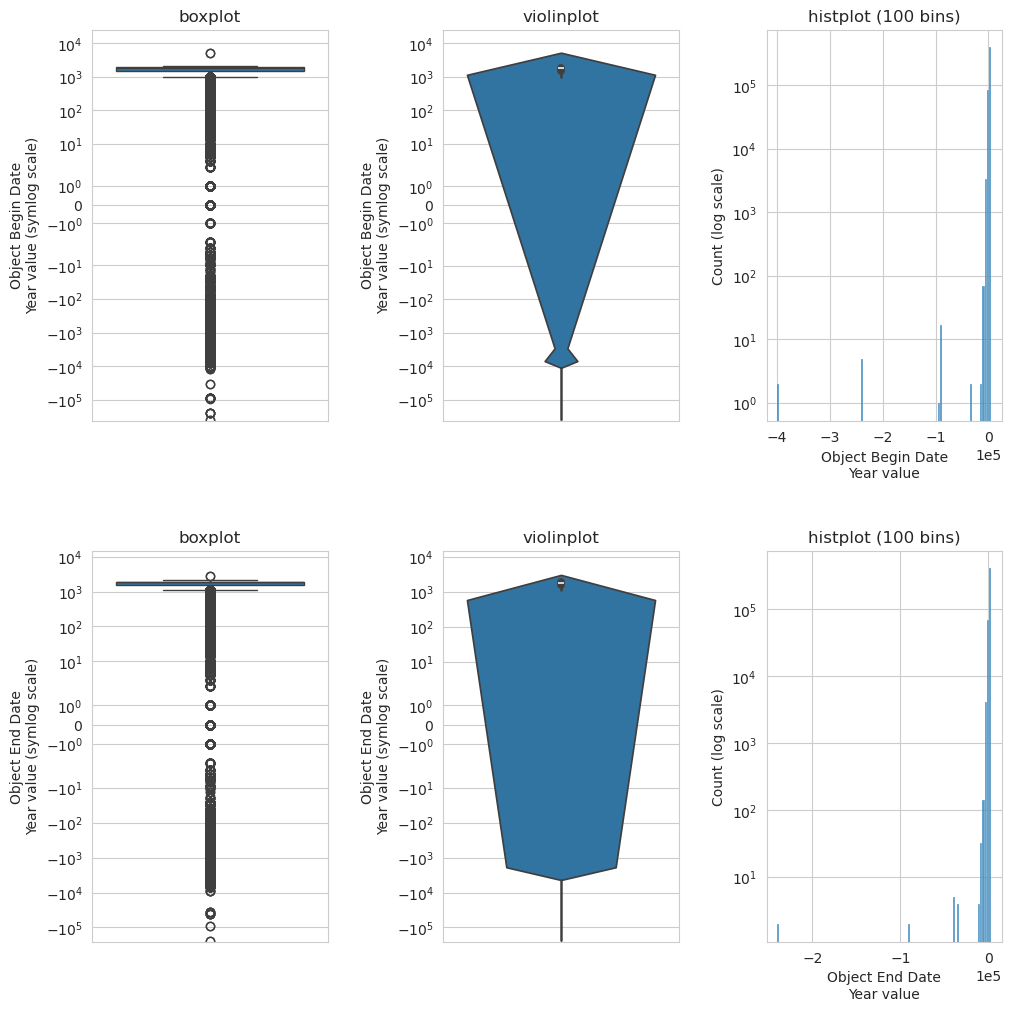

In [82]:
plots_types = [(data, plot_fn) for data in [ser_obj_beg_dt, ser_obj_end_dt] for plot_fn in
               [sns.boxplot, sns.violinplot, sns.histplot]]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 10), constrained_layout=True,
                         gridspec_kw={'wspace': 0.1, 'hspace': 0.1})

for idx, (data, plot_fn) in enumerate(plots_types):
    ax = axes[idx // 3, idx % 3]

    title = plot_fn.__name__
    if plot_fn == sns.histplot:
        bins = 100
        plot_fn(data, bins=100, ax=ax)
        title = title + f' ({bins} bins)'
        ax.set_yscale('log')
        ax.set_ylabel(f'{ax.get_ylabel()} (log scale)')
        ax.set_xlabel(f'{ax.get_xlabel()}\nYear value')
        ax.ticklabel_format(style='sci', axis='x', scilimits=(-3, 3))
    else:
        plot_fn(data, ax=ax)
        ax.set_yscale('symlog')
        ax.set_ylabel(f'{ax.get_ylabel()}\nYear value (symlog scale)')
    ax.set_title(title)

plt.show()

We already see, that there are a lot of outliers. Let's examine those values:

In [83]:
def IQR_lower_upper_bounds(data: pd.Series) -> (float, float):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound


def get_IQR_outliers(data: pd.Series) -> pd.Series:
    lower, upper = IQR_lower_upper_bounds(data)
    return data[(data < lower) | (data > upper)]

In [93]:
print(f'IQR lower and upper bounds respectively: {IQR_lower_upper_bounds(ser_obj_beg_dt)}')
beg_dt_outliers = get_IQR_outliers(ser_obj_beg_dt).drop_duplicates()
print('Largest outliers:')
display(beg_dt_outliers.nlargest(5))
print('Smallest outliers:')
display(beg_dt_outliers.nsmallest(5))

IQR lower and upper bounds respectively: (1001.0, 2425.0)
Largest outliers:


336740    5000
17881     1000
32019      999
312616     997
303112     996
Name: Object Begin Date, dtype: int64

Smallest outliers:


364683   -400000
364677   -240000
366420    -95000
347936    -90000
347938    -35000
Name: Object Begin Date, dtype: int64

First:
- there are outliers with year lying in the future 
- if we look at our lower and upper bounds, we will see, that those outliers negatively affected our bounds, making upper bound in year 2425, far in the future 
- such outliers should be deleted (replaced with NaN), so they do not affect the data


Second:
- Some values have negative dates, which is OK, because those represent years BC and are valid values. 


Let's look at that value with `-400000` value:
 

In [95]:
df_objects.iloc[364683]

Object Number                                                      06.322.48
Is Highlight                                                           False
Is Timeline Work                                                       False
Is Public Domain                                                        True
Object ID                                                             573096
Gallery Number                                                           NaN
Department                                                      Egyptian Art
AccessionYear                                                           1906
Object Name                                    Tool, Biface, Hand-axe, Ovate
Title                              Biface, commonly referred to as a hand ax
Culture                                                                  NaN
Period                                              Lower Paleolithic Period
Dynasty                                                                  NaN

- it is a hand axe
- it is some Egyptian Art 
- it's begin date is `-400000` and end date is `-240000`
- clearly, those dates represent a span of years when this axe could be created
- it corresponds to Old Stone Age with timeframe ~3.3M years to 10000 BCE

Let's look how many Stone Age values are there (~3.3M years ago to ~2000 BCE, after which follows the Bronze Age)

In [100]:
print(f'Count of Stone Age years: {(ser_obj_beg_dt < -2000).sum()}')
print(f'Ratio of Stone Age years: {(100 * ser_obj_beg_dt < -2000).sum() / len(ser_obj_beg_dt.dropna()):.2f}%')

Count of Stone Age years: 7530
Ratio of Stone Age years: 0.14%


There are not so many such values. That is why it didn't affected our outliers lower bound too much.

We will briefly look at the Object End Check, expecting same situation there:

In [102]:
print(f'IQR lower and upper bounds respectively: {IQR_lower_upper_bounds(ser_obj_end_dt)}')
beg_dt_outliers = get_IQR_outliers(ser_obj_end_dt).drop_duplicates()
print('Largest outliers:')
display(beg_dt_outliers.nlargest(5))
print('Smallest outliers:')
display(beg_dt_outliers.nsmallest(5))

IQR lower and upper bounds respectively: (1125.0, 2373.0)
Largest outliers:


247168    2870
231817    2835
309786    1124
318734    1123
65195     1120
Name: Object End Date, dtype: int64

Smallest outliers:


364683   -240000
347942    -90000
364677    -40000
347936    -35000
198884     -9300
Name: Object End Date, dtype: int64


As we can see, situation is very similar for the Object End Date. Same thought processes may be applied here.


There is also another interesting insight - some of the invalid years lying in the future may be just a typing mistake. Let's see the object with end date `2870`:

In [103]:
df_objects.iloc[247168]

Object Number                                                    23.112.1595
Is Highlight                                                           False
Is Timeline Work                                                       False
Is Public Domain                                                        True
Object ID                                                             379662
Gallery Number                                                           NaN
Department                                               Drawings and Prints
AccessionYear                                                           1923
Object Name                                                          Drawing
Title                                             Design for Landau, no. 958
Culture                                                                  NaN
Period                                                                   NaN
Dynasty                                                                  NaN

If we substitute `2` with `1` we will get object end date `1870`, while object begin date is `1850`. Given the context of the object, those dates make sense now. Thus, we now may expect, that many outliers can be fixed just by subtracting `1000` from the end date, and checking if begin date is not after the end date. 

**In conclusion:**

- we found outliers in two features, usig standard techniues for outliers detection with some visualizations
- we interpreted those outliers, why they appear there, and how they affect the data
- we found important insights, that some outliers can be fixed by making appropriate transformations, not only fixing problem with outliers, but making our data more complete, consistent and integral.

# 5. Missing Values

Let's explore missings in both objects and artists datasets:

In [109]:
df_objects.isna().mean().round(4) * 100

Object Number                0.00
Is Highlight                 0.00
Is Timeline Work             0.00
Is Public Domain             0.00
Object ID                    0.00
Gallery Number              89.78
Department                   0.00
AccessionYear                0.80
Object Name                  0.47
Title                        5.94
Culture                     57.07
Period                      81.21
Dynasty                     95.22
Reign                       97.68
Portfolio                   94.53
Object Date                  2.77
Object Begin Date            0.00
Object End Date              0.00
Medium                       1.49
Dimensions                  15.48
Credit Line                  0.13
Geography Type              87.64
City                        93.25
State                       99.46
County                      98.24
Country                     84.33
Region                      93.50
Subregion                   95.43
Locale                      96.75
Locus         

In [110]:
df_artists.isna().mean().round(4) * 100

Object ID               0.00
Constituent ID         31.21
Role                   31.21
Prefix                 31.21
Display Name           31.21
Display Bio            31.55
Suffix                 31.22
Alpha Sort             31.21
Nationality            31.21
Begin Date             31.21
End Date               31.21
Gender                 97.64
ULAN URL               54.06
Wikidata URL           55.41
Constituents Number    31.21
Constituent Order      31.21
Artist ID              71.49
dtype: float64

We will explore missings in:
- **Artist Prefix** column
- **Classification** column
- **Tags** column

After that we will choose a feature for imputation and will try some imputation on it.

## Artist Prefix

In [128]:
df_art_prefix = pd.DataFrame(df_artists['Prefix'])
introduce_data(df_art_prefix, column='Prefix')
df_art_prefix.head()

count     446206
unique      3823
top             
freq      326080
Name: Prefix, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 648659 entries, 0 to 648658
Series name: Prefix
Non-Null Count   Dtype 
--------------   ----- 
446206 non-null  object
dtypes: object(1)
memory usage: 4.9+ MB


None

Number of NaN values: 202453 (31.21%)


,Prefix
0,
1,
2,NaN
3,NaN
4,NaN


As we already see, there are values that are empty strings or whitespaces.

We will perform missings detection by:
- looking at largest and smallest values (string length)
- making frequency analysis
- in general, when looking for missings, we may expect to find different representations of missing values, like empty strings, '??' or 'Missing'

### Largest & smallest (by string length)

In [134]:
df_art_prefix['Prefix Length'] = df_art_prefix['Prefix'].apply(
    lambda x: len(x.strip()) if isinstance(x, str) else np.NaN)

In [139]:
print('Largest prefix length:')
display(df_art_prefix.drop_duplicates().nlargest(5, columns='Prefix Length'))
print('\nSmallest prefix length:')
display(df_art_prefix.drop_duplicates().nsmallest(5, columns='Prefix Length'))

Largest prefix length:


,Prefix,Prefix Length
20241,"Upper plate of the gorget, skirt lames, and ch...",64.0
20216,Helmet cheek pieces and metal plates on should...,63.0
22256,Knife handle (kozuka) and grip ornaments (menu...,63.0
631413,"Jewel animals, amorini, and figurines of the l...",62.0
115133,Enamel scene of St. John the Baptist based on ...,61.0



Smallest prefix length:


,Prefix,Prefix Length
0,,0.0
256096,v,1.0
258372,\,1.0
263525,P,1.0
264856,?,1.0


For largest lengths it looks quite normal. But for smallest, we already see that something is not good. We will explore unique values across smallest prefix lengths: 

In [143]:
for l in range(1, 5):
    print(f'Unique values with prefix length {l}:')
    display(df_art_prefix[df_art_prefix['Prefix Length'] == l]['Prefix'].unique())
    print()

Unique values with prefix length 1:


array(['v', '\\', 'P', '?'], dtype=object)


Unique values with prefix length 2:


array(['or', 'a)', 'c)', 'a.', 'at', 'By', '7:', '1:', '3:', 'by', 'Or',
       'De', 'as'], dtype=object)


Unique values with prefix length 3:


array(['(a)', '(e)', 'for', '(i)', '(b)', '(c)', '(d)', '(f)', '(n)',
       '(g)', 'For', '(l)', 'and', '(?)', '10:', '11:', 'Cut', 'And',
       'Par', 'the', '(6)', '(1)', '(5)', '(4)'], dtype=object)


Unique values with prefix length 4:


array(['(a.)', '(b.)', 'a-c.', 'a-b.', 'From', '2-5:', '7&8:', 'with',
       'fter', 'ater', 'Chez', 'Imp.', 'Afer', 'Monk', '(13)', '(83)',
       '(39)', '(79)', '(44)', '(40)', '(64)', '(82)', '(75)', '(95)',
       '(98)', '(96)', '(88)', '(76)', '(97)', '(93)', '(68)', '(22)',
       '(66)', '(58)', '(26)', '(24)', '(25)', '(69)', '(31)', '(34)',
       '(46)', '(73)', '(57)', '(53)', '(63)', '(71)', '(29)', '(17)',
       '(20)', '(19)', '(21)'], dtype=object)

There are a lot of strange values, like '?', 'P', '\\', 'v' or '(?)'. Let's see actual artists with such values:

In [158]:
df_artists[df_art_prefix['Prefix'].isin({'v', '\\', 'P', '?', '(?)'})].drop_duplicates(subset=['Prefix'])

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
236927,342703,16228616189,Artist,(?),Francesco Francia,"Italian, Bologna ca. 1447–1517 Bologna",,"Francia, Francesco",Italian,1447,1517,NaN,http://vocab.getty.edu/page/ulan/500115527,https://www.wikidata.org/wiki/Q260057,2.0,1.0,NaN
256096,351081,16550,Publisher,v,Grands Magasins du Louvre,French,", Paris",Grands Magasins du Louvre,French,,,NaN,NaN,NaN,1.0,0.0,16550.0
258372,351955,1623688319,Illustrator,\,Bernard Salomon,"French, ca. 1508–ca. 1561",,"Salomon, Bernard",French,1508,1561,NaN,http://vocab.getty.edu/page/ulan/500015400,https://www.wikidata.org/wiki/Q2898582,2.0,0.0,NaN
263525,353978,717758495218249,Publisher,P,Willis P. Hazard,"Philadelphia, Pennsylvania",,"Hazard, Willis P.",American,1750,1850,NaN,NaN,NaN,3.0,1.0,NaN
264856,354473,853581915908621,Artist,?,Manuel Manilla,"Mexican, Mexico City ca. 1830–1895 Mexico City",,"Manilla, Manuel",Mexican,1830,1895,NaN,http://vocab.getty.edu/page/ulan/500347966,https://www.wikidata.org/wiki/Q1556749,3.0,1.0,NaN


If we expect the dataset further, we will see, that '?' and '(?)' represent the majority of the subset. Values 'v', 'P' and '\\' occur only once. Most likely those are typing mistakes. Of the examined values should be replaces with NaN.

### Frequency Analysis

In [156]:
df_art_prefix.value_counts(subset='Prefix', normalize=True).head()

Prefix
                 0.730784
Issued by        0.066534
After            0.058395
Published by     0.019657
Attributed to    0.010094
Name: proportion, dtype: float64

73% of non-NaN values are empty strings. 

Now, let's replace all of the found invalid values with np.NaN:

In [162]:
df_art_prefix['Prefix'] = df_art_prefix['Prefix'].str.strip().replace({'v', '\\', 'P', '?', '(?)', ''}, np.NaN)
introduce_data(df_art_prefix, column='Prefix')
df_art_prefix.value_counts(subset='Prefix', normalize=True).head()

count        119780
unique         3813
top       Issued by
freq          29688
Name: Prefix, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 648659 entries, 0 to 648658
Series name: Prefix
Non-Null Count   Dtype 
--------------   ----- 
119780 non-null  object
dtypes: object(1)
memory usage: 4.9+ MB


None

Number of NaN values: 528879 (81.53%)


Prefix
Issued by        0.247854
After            0.217532
Published by     0.073226
Attributed to    0.037894
Designed by      0.027876
Name: proportion, dtype: float64

## Classification

In [5]:
df_class = df_objects[['Object ID', 'Classification']].copy()
introduce_data(df_class, column='Classification')

count     406239
unique      1244
top       Prints
freq       84326
Name: Classification, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Classification
Non-Null Count   Dtype 
--------------   ----- 
406239 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 78717 (16.23%)


In [6]:
df_class['Classification'].unique()

array([nan, 'Metalwork-Brass', 'Metalwork-Pewter', ...,
       'Prints|Enamels-Translucent',
       'Ornament & Architecture|Textiles-Embroidered',
       'Ephemera|Ornament & Architecture'], dtype=object)

Some objects have multiple classifications. The correct way to treat such columns will be the same as with artists - extract it as a separate dataset, and if needed join with the rest by Object ID. The reason is that there may be missing values inside the joined lists, like 'Gold|\<missing\>|Silver'. If there are other missings, like '??' or empty strings, we will still see them (unless there are whole values same as delimeters).


We will split values by '|', '&' and '/' (frequent separators if we examine more the data), and then we will analyze missings.

In [7]:
def split_classification_keywords(value):
    if isinstance(value, str):
        return re.split(r'\||&|/', value)
    return value

In [8]:
df_class['Classifications List'] = df_class['Classification'].apply(split_classification_keywords)
df_class_long = df_class.explode('Classifications List').drop('Classification', axis=1).rename(
    {'Classifications List': 'Classification'}, axis='columns')
df_class_long.dropna().head()

,Object ID,Classification
4843,5209,Metalwork-Brass
4844,5210,Metalwork-Brass
7338,7829,Metalwork-Pewter
8710,9367,Ceramics
12564,13737,Textiles


Last thing will be to perform lowercasing and whitespaces reduction:

In [32]:
df_class_long['Classification'] = df_class_long['Classification'].apply(lowercase).apply(whitespaces_reduction)
introduce_data(df_class_long, column='Classification')

count     498872
unique       789
top       prints
freq      127450
Name: Classification, dtype: object

<class 'pandas.core.series.Series'>
Index: 577589 entries, 0 to 484955
Series name: Classification
Non-Null Count   Dtype 
--------------   ----- 
498872 non-null  object
dtypes: object(1)
memory usage: 8.8+ MB


None

Number of NaN values: 78717 (13.63%)


We reduced number of unique values roughly by 1/3. Now let's explore missing values there:
- largest & smallest values analysis (by value length)
- frequency analysis
- values with punctuation characters

### Largest & smallest (by length) 

In [18]:
df_class_long['Classification Length'] = df_class_long['Classification'].apply(
    lambda x: len(x) if isinstance(x, str) else np.NaN).astype('Int32')
print('Largest prefix length:')
display(df_class_long.drop_duplicates(subset='Classification').nlargest(5, columns='Classification Length'))
print('\nSmallest prefix length:')
display(df_class_long.drop_duplicates(subset='Classification').nsmallest(5, columns='Classification Length'))

Largest prefix length:


,Object ID,Classification,Classification Length
140521,241098,"textiles: sheets, shrouds, bandages [see cloth...",60
339874,505703,"modern (casts, models, display material, impre...",53
113958,203685,Scientific Instruments-Barometers and Thermome...,50
335245,500630,Aerophone-Blow Hole-side-blown flute (transverse),49
405494,695101,"relief [see also architecture, stelae, palettes]",48



Smallest prefix length:


,Object ID,Classification,Classification Length
33989,39861,Ink,3
17483,22037,Mail,4
30373,36044,Jade,4
30405,36077,Inrō,4
30414,36086,Fans,4


Seemingly no problems.

### Frequency Analysis

In [19]:
df_class_long.value_counts(subset='Classification', normalize=True).head()

Classification
Prints         0.255476
Ephemera       0.085976
Photographs    0.079696
Drawings       0.058771
Vases          0.042787
Name: proportion, dtype: float64

Again, seems there are no problems with that too.

### Punctuation

We will use string.punctuation with excluded '-', because many values have dash separated words, and it is highly unlikely, that other represenation of missing will have that symbol.

In [20]:
def contains_punctuation(value):
    if isinstance(value, str):
        return any(char in set('!"#$%&\'()*+,./:;<=>?@[\\]^_`{|}~') for char in value)
    return False

In [21]:
df_class_long[df_class_long['Classification'].apply(contains_punctuation)]['Classification'].unique()

array(['Armor Parts-Colletins, Parts', "Armor Parts-Manteau d'arm",
       "Archery Equipment-Archer's Ring",
       'Sword Furniture-Fittings, Sets of', '(not assigned)',
       "Main dress-Childrenswear-Boy's",
       "Main dress-Childrenswear-Girl's",
       'textiles: sheets, shrouds, bandages [see clothing, painting]',
       'Miscellaneous-Bone, Ivory',
       'Jewelry, Precious Metals and Precious Stones',
       'Aerophone-Blow Hole-end-blown flute (vertical)',
       'Aerophone-Blow Hole-side-blown flute (transverse)',
       'Models - Actions, valve system, etc',
       'modern (casts, models, display material, impressions)',
       'relief [see also architecture, stelae, palettes]'], dtype=object)

As we actually see, there is '(not assigned)' value, which represents a missing value. We will replace it with NaN:

In [22]:
df_class_long['Classification'] = df_class_long['Classification'].replace('(not assigned)', np.NaN)

Now we have finished with detection of missing in **Classification** column.

## Tags

In [9]:
df_tags = df_objects[['Object ID', 'Tags']].copy()
introduce_data(df_tags, column='Tags')
df_tags.dropna().head()

count      192455
unique      44171
top       Flowers
freq         8543
Name: Tags, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Tags
Non-Null Count   Dtype 
--------------   ----- 
192455 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 292501 (60.31%)


,Object ID,Tags
6,7,Birds|Coins
7,8,Eagles|Men|Profiles
32,33,Men|Abraham Lincoln|Portraits
33,34,Landscapes|Boats
34,35,Animals|Garlands|Birds|Men


We have quite similar situation as with Classification. Thus, we will perform same procedures:

In [10]:
df_tags['Tags List'] = df_tags['Tags'].str.split('|')
df_tags_long = df_tags.explode('Tags List').drop('Tags', axis='columns').rename({'Tags List': 'Tag'}, axis='columns')
df_tags_long.dropna().head()

,Object ID,Tag
6,7,Birds
6,7,Coins
7,8,Eagles
7,8,Men
7,8,Profiles


In [11]:
print(f'Number of unique tags: {df_tags_long["Tag"].nunique()}')

Number of unique tags: 1154


Quite a lot of tags. Let's apply some transformation (lowercasing, whitespace reduction and punctuation reduction) to see if that will reduce unique values number:

In [14]:
unique_tags_number = df_tags_long['Tag'].apply(lowercase).apply(whitespaces_reduction).apply(
    special_characters_reduction).nunique()
print(f'Number of unique tags after transformations: {unique_tags_number}')

Number of unique tags after transformations: 1154


Tags are consistent and there is no point to apply transformations on them.



### Largest & smallest (by string length)

In [15]:
df_tags_long['Tag Length'] = df_tags_long['Tag'].apply(lambda x: len(x) if isinstance(x, str) else np.NaN).astype(
    'Int32')
print('Largest prefix length:')
display(df_tags_long.drop_duplicates(subset='Tag').nlargest(5, columns='Tag Length'))
print('\nSmallest prefix length:')
display(df_tags_long.drop_duplicates(subset='Tag').nsmallest(5, columns='Tag Length'))

Largest prefix length:


,Object ID,Tag,Tag Length
11186,12204,Adoration of the Shepherds,26
104359,193423,Saint John the Evangelist,25
97651,186225,Coronation of the Virgin,24
104500,193576,Assumption of the Virgin,24
11174,12192,Descent from the Cross,22



Smallest prefix length:


,Object ID,Tag,Tag Length
10209,11081,Ox,2
7,8,Men,3
4621,4986,Sun,3
9827,10610,Fog,3
10044,10872,Sky,3


No anomalies detected.

### Frequency Analysis

In [16]:
df_tags_long.value_counts(subset='Tag', normalize=True).head()

Tag
Men          0.132948
Women        0.090439
Portraits    0.066185
Flowers      0.041079
Birds        0.019964
Name: proportion, dtype: float64

From frequency analysis we too see no anomalies.

Seems like Tags feature has no problems with missing values, but at least we transformed it to a better representation.

## Imputation

First of all, let's look at all columns in both objects and artists datasets:

In [6]:
def imputation_stats(data: pd.DataFrame):
    df_imp_stats = pd.concat([data.nunique(), data.isna().mean().round(4) * 100], axis='columns')
    df_imp_stats.columns = ['unique values', 'missing values ratio']
    return df_imp_stats.T

In [38]:
imputation_stats(df_objects)

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
unique values,481656.0,2.0,2.0,2.0,484956.0,379.00,19.0,180.0,28631.00,245800.00,...,228.00,1244.00,1507.00,484956.0,69076.00,0.0,1.0,44171.00,43699.00,43886.00
missing values ratio,0.0,0.0,0.0,0.0,0.0,89.78,0.0,0.8,0.47,5.94,...,99.57,16.23,94.94,0.0,85.74,100.0,0.0,60.31,60.31,60.31


In [39]:
imputation_stats(df_artists)

,Object ID,Constituent ID,Role,Prefix,Display Name,Display Bio,Suffix,Alpha Sort,Nationality,Begin Date,End Date,Gender,ULAN URL,Wikidata URL,Constituents Number,Constituent Order,Artist ID
unique values,484956.0,48365.00,85.00,3823.00,58035.00,34415.00,2031.00,58012.00,765.00,1135.00,1098.00,1.00,15971.00,19876.00,63.00,136.00,9361.00
missing values ratio,0.0,31.21,31.21,31.21,31.21,31.55,31.22,31.21,31.21,31.21,31.21,97.64,54.06,55.41,31.21,31.21,71.49


Ideally, we want to impute columns, where missing values ratio is low, and it is either numeric or categorical with number of unique values as low as possible.

### Classification Column Imputation

We will try kNN to impute classification column values:
- we will not use KNNImputer, because it tries to impute all values for each column. But in our case, we want: 
    - impute only one column - Classification
    - evaluate our imputer using accuracy and get right hyperparameters for our imputer

In [40]:
imputation_stats(df_class_long)

,Object ID,Classification
unique values,484956.0,789.00
missing values ratio,0.0,13.63


Classification column is good for imputation for two reasons:
- it has low missing values ratio, that means we have a lot of labeled data from which we can impute.
- it has only 789 unique values, which is less than one percent of the whole dataset values.

Classification column is not good for imputation for two reasons:
- it is a categorical data type, which leads to some kind of classification task, but with too mane labels.
- for missing values we don't know how many classifications are there, because initially we had a list of classes for an object. Here, we can assign only one class and we don't know if we need to assign another one.
    - possible solution for that would be get top n most probable classes and use some threshold probability to assign classes to an object.


Nonetheless, we will at least try it and see how effective we were.

#### Dataset Preparation


In [17]:
pd.merge(left=df_class_long, right=df_tags, on='Object ID', how='left',

,Object ID,Classification
0,1,NaN
1,2,NaN
2,3,NaN
3,4,NaN
4,5,NaN
...,...,...
484951,900605,Prints
484952,900606,Prints
484953,900633,Prints
484954,900717,NaN


# 6. Medium feature cleaning

Our task is to use this feature for classification using kNN algorithm. Let's look at the feature:

In [6]:
df_medium=df_objects[['Object ID', 'Medium']].copy()
introduce_data(df_medium, 'Medium')

count         477741
unique         65907
top       Terracotta
freq           23514
Name: Medium, dtype: object

<class 'pandas.core.series.Series'>
RangeIndex: 484956 entries, 0 to 484955
Series name: Medium
Non-Null Count   Dtype 
--------------   ----- 
477741 non-null  object
dtypes: object(1)
memory usage: 3.7+ MB


None

Number of NaN values: 7215 (1.49%)


**65907** unique values.

kNN algorithm works with distance metric to make classification. Categorical nominal feature cannot be used with kNN, because kNN expects ordinality and concept of distance between points. What distance can be there between 'gold' and 'silver'? Thus, we need to represent this feature differently.

Multi-hot encoding can be used for that purpose, but as we know, kNN has problems with high-dimensional data, and 65 thousands features may degrade quality of classification significantly.

Thus, we will try to reduce amount of unique values in **Medium**, and at the end we will pick up only first N features by values count. 

In [7]:
# data from nltk
nltk.download('words', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

### Uniqueness Reduction

We will use NLTK to tokenize longer strings and filter out stop words.

We will also use several transformations:
- lowercasing
- whitespace reduction
- special characters reduction
- spellchecking
- lemmatization

Let's examine how simple transformations affect uniqueness:

In [8]:
def chain_transformation_function(*transformations):
    def chain_transformation(value: str):
        if not isinstance(value, str):
            return value
        result = value
        for func in transformations:
            result = func(result)
        return result

    return chain_transformation

In [9]:
display_top_n_dict(
    unique_difference(chain_transformation_function(lowercase, whitespaces_reduction, special_characters_reduction),
                      df_medium['Medium']))

Number of unique values before chain_transformation: 65907
Number of unique values after chain_transformation: 61550
Difference: 4357
Ratio of values with different cases to all uniques before chain_transformation: 0.07
Top 5 examples:


[('gold', {'GOLD', 'Gold', 'Gold\r\n', 'Gold,', 'gold', 'gold\r\n', 'gold '}),
 ('silver',
  {'SILVER',
   'SIlver',
   'Silver',
   'Silver\r\n',
   'Silver(?)',
   'Silver?',
   'silver'}),
 ('paper', {'Paper', 'Paper.', 'paper'}),
 ('brass',
  {'Brass', 'Brass\r\n', 'Brass\r\n\r\n', 'Brass.', 'brass', 'brass(?)'}),
 ('iron', {'IRON', 'Iron', 'Iron\r\n', 'Iron?', 'iron'})]

Using only simple transformations we reduced number of unique values only by 7%.
 
Some medium keywords are marked with '?' to express uncertainty. It is a good question, how to approach such values. In our case we will simply ignore uncertainty. 

There is one significant problem - if we look at values, we can see, that often there are whole sentences:

In [10]:
df_medium.iloc[484848]

Object ID                               900102
Medium       Etching on thin white Japan paper
Name: 484848, dtype: object

Clearly there are words that are not necessary for classification task, like 'on', 'and', 'a', 'the' - stopwords.

We will use NLTK to tokenize text, and also split words by characters like '-' and '\', along with removing empty strings.

In [11]:
def tokenize(text: str | None) -> set | None:
    if not isinstance(text, str):
        return text
    text_lower = text.lower()
    tokens = word_tokenize(text_lower)
    cleaned_tokens = set()
    for token in tokens:
        subtokens = re.split(r'\\|/|-', token)
        for subtoken in subtokens:
            cleaned = special_characters_reduction(subtoken)
            cleaned = re.sub(r'[^a-zA-Z]', '', cleaned)
            if len(cleaned) > 0:
                cleaned_tokens.add(cleaned)
    return cleaned_tokens

In [12]:
df_medium['Medium (Tokenized)'] = df_medium['Medium'].apply(tokenize)

In [13]:
df_medium_long = df_medium[['Object ID', 'Medium (Tokenized)']].rename(
    columns={'Medium (Tokenized)': 'Medium'}).explode(
    'Medium')

In [14]:
display(df_medium_long.drop_duplicates(subset='Medium').head())
print(
    f'Number of unique values after tokenization: {df_medium_long.drop_duplicates(subset="Medium")["Medium"].nunique()}')

,Object ID,Medium
0,1,gold
14,15,silver
15,16,bronze
15,16,copper
15,16,or


Number of unique values after tokenization: 8328


We reduced number of unique values to **8328** as opposed to **65907**, which is a great result. Of course, we lost some information, or distorted some information, but for our task this drawbacks are negligible.

Now we need to finish our preprocessing:
- filter out stopwords, as the `or` we can see there
- use spellcheck
- use lemmatizer
- make frequency analysis, looking at frequent data (in future our features) and remove values that should not be there.
- make string length analysis, to again, remove values that may be incorrect.

All our next operations we will perform on unique words subset, creating a mapping structure, which we will apply later on the whole dataset. The reason is that currently the medium_exploded dataset contains **1 533 881** rows, many of them are the same. It will be computationally intensive to process every of them.

In [15]:
def remove_stopwords(word: str | float) -> str | float:
    if not isinstance(word, str):
        return word
    if word in stopwords.words('english'):
        return np.NaN
    return word

In [16]:
stopwords_removal_mapping = dict()
unique_words = df_medium_long['Medium'].dropna().unique()
for word in unique_words:
    stopwords_removal_mapping[word] = remove_stopwords(word)

In [17]:
df_medium_long['Medium'] = df_medium_long['Medium'].apply(
    lambda x: stopwords_removal_mapping[x] if isinstance(x, str) else np.NaN)
display(df_medium_long.drop_duplicates(subset='Medium').head())
print(
    f'Number of unique values after tokenization: {df_medium_long.drop_duplicates(subset="Medium")["Medium"].nunique()}')

,Object ID,Medium
0,1,gold
14,15,silver
15,16,bronze
15,16,copper
15,16,NaN


Number of unique values after tokenization: 8229


Removing stopwords, we reduced number of unique values from **8328** to **8229**, which isn't much, but stopwords may have high values count and they are not suitable predictors.

Now we will proceed with spellchecking and lemmatization:

In [18]:
spell_lemm_mappings = dict()
unique_words = df_medium_long['Medium'].dropna().unique()

In [133]:
spell = SpellChecker()
lemmatizer = WordNetLemmatizer()

for word in tqdm(unique_words):
    spellchecked = spell.correction(word)
    if spellchecked is None:
        spell_lemm_mappings[word] = word
    else:
        spell_lemm_mappings[word] = lemmatizer.lemmatize(spellchecked)


100%|██████████| 8229/8229 [14:31<00:00,  9.44it/s]


Because spellchecking computationally is very intensive, we will save mappings into a file using pickle:

In [19]:
if spell_lemm_mappings is None or len(spell_lemm_mappings) > 0:
    with open('spellcheck_lemmatized.pickle', 'wb') as file:
        pickle.dump(spell_lemm_mappings, file)
        print('Dump success.')
else:
    with open('spellcheck_lemmatized.pickle', 'rb') as file:
        spell_lemm_mappings = pickle.load(file)
        print('Load success.')

Load success.


In [20]:
mappings_list = [f'{key} -> {value}' for key, value in spell_lemm_mappings.items() if key != value]
print(f'Number of corrections: {len(mappings_list)}')
mappings_list[:10]

Number of corrections: 3120


['tourmalines -> tourmaline',
 'pearls -> pearl',
 "quartzes -> quartz's",
 'spessartites -> spessartite',
 'amethysts -> amethyst',
 'fravrile -> fragile',
 'edges -> edge',
 'braces -> brace',
 'vera -> very',
 'prima -> prime']

If we will inspect successfulness of spellchecker and lemmatizer, we will see, that sometimes spellcheck gives wrong corrections.

For examples, the spellchecker cannot spellcheck word 'italy'. Thus, we should be more careful about its use, ideally inspect deeper how it affects keywords quality, and if the drawbacks are negligible enough, then just ignore them.

In [21]:
df_medium_long['Medium'] = df_medium_long['Medium'].apply(
    lambda x: spell_lemm_mappings[x] if isinstance(x, str) and x in spell_lemm_mappings else np.NaN)
display(df_medium_long.drop_duplicates(subset='Medium').head())
print(
    f'Number of unique values after spellchecking and lemmatization: {df_medium_long.drop_duplicates(subset="Medium")["Medium"].nunique()}')

,Object ID,Medium
0,1,gold
14,15,silver
15,16,bronze
15,16,copper
15,16,NaN


Number of unique values after spellchecking and lemmatization: 6455


Now we have **6455** unique values, which is quite impressive reduction from overall **65907**.

Let's finish our analysis by string length and frequency analysis:

In [22]:
df_medium_long['Medium (string length)'] = df_medium_long['Medium'].apply(
    lambda x: len(x) if isinstance(x, str) else x).astype('Int32')
print('Largest prefix length:')
display(df_medium_long.drop_duplicates(subset='Medium').nlargest(5, columns='Medium (string length)'))
print('\nSmallest prefix length:')
display(df_medium_long.drop_duplicates(subset='Medium').nsmallest(5, columns='Medium (string length)'))

Largest prefix length:


,Object ID,Medium,Medium (string length)
149614,250427,terracottaworkshop,18
211799,342990,photoreproductions,18
453994,778065,chromolithigraphed,18
102566,191372,glazedearthenware,17
108936,198291,cryptocrystalline,17



Smallest prefix length:


,Object ID,Medium,Medium (string length)
15270,16680,b,1
16343,19287,i,1
30406,36078,e,1
30457,36131,a,1
33960,39829,c,1


The longest words, like `terracottaworkshop` seem suspicious, because we could split this word into two separate words. If we look at the original dataset, we will see, that those words are there same as we have it here (so there is no mistake in our preprocessing):

In [23]:
df_objects.iloc[149614]['Medium']

'Terracottaworkshop'

It is not trivial task to split such words, so we will leave them.

Looking at the shortest words, we see, that there are a lot of values that do not represent any keyword:

In [24]:
for l in range(1, 4):
    cap = 50
    print(f'Unique values with prefix length {l} (max first {cap} values):')
    unique = df_medium_long[df_medium_long['Medium (string length)'] == l]['Medium'].unique()
    display(unique[:min(cap, len(unique))])
    print()

Unique values with prefix length 1 (max first 50 values):


array(['b', 'i', 'e', 'a', 'c', 'z', 'x', 'w', 'r', 'n', 'f', 'j', 'g',
       'k', 'l', 'h', 'q', 'p', 'u', 'v', 'm'], dtype=object)


Unique values with prefix length 2 (max first 50 values):


array(['it', 'de', 'ox', 'to', 'si', 'do', 'yo', 'in', 'on', 'we', 'ye',
       'ki', 'ai', 'he', 'ya', 'go', 'sh', 'et', 'be', 'la', 'of', 'ad',
       'eh', 'dg', 'oh', 'hl', 'am', 'en', 'so', 'me', 'nu', 'or', 'ab',
       'va', 'my', 're', 'hi', 'as', 'li', 'xu', 'up', 'bi', 'kc', 'no',
       'ex', 'xi', 'an', 'em', 'od', 'pa'], dtype=object)


Unique values with prefix length 3 (max first 50 values):


array(['oak', 'ash', 'top', 'gum', 'red', 'ink', 'pen', 'tin', 'non',
       'eye', 'oil', 'wax', 'cut', 'two', 'elm', 'bay', 'jet', 'sub',
       'end', 'new', 'tan', 'mat', 'gun', 'net', 'man', 'set', 'she',
       'vat', 'one', 'ply', 'pop', 'air', 'hat', 'lid', 'box', 'die',
       'lap', 'dux', 'pin', 'say', 'ray', 'fur', 'doe', 'yak', 'egg',
       'cow', 'gut', 'ivy', 'elk', 'pot'], dtype=object)

We have quite a lot of words with length 1, 2 and 3, that doesn't make sense here as keywords. Moreover, we see that stopwords are still there. This is because the spellchecker corrected some words into those stopwords.

This should not be a problem, unless those words have high value counts, which will affect whether this feature will be used for one-hot encoding or not. Thus, we will be aware of it, remove only one-character values, and ignore the rest until we see an obvious problem with them.

In [25]:
one_character_values = {'b', 'i', 'e', 'a', 'c', 'z', 'w', 'x', 'r', 'n', 'f', 'k', 'h',
                        'j', 'l', 'g', 'q', 'p', 'u', 'v', 'm'}
df_medium_long['Medium'] = df_medium_long['Medium'].apply(lambda x: x if x not in one_character_values else np.NaN)


Now, let's do some frequency analysis:

In [26]:
ser_medium_long_vc = df_medium_long.value_counts(subset='Medium')
ser_medium_long_vc.head()

Medium
etching       43438
lithograph    39348
color         36697
silver        36408
print         34449
Name: count, dtype: int64

With manual look at first 100 values, we can spot some keywords that don't make sense in this context, which should be removed:

In [27]:
to_remove = {'color', 'two', 'second', 'third', 'first', 'three', 'four'}

In [28]:
df_medium_long['Medium'] = df_medium_long['Medium'].apply(lambda x: x if x not in to_remove else np.NaN)

Finally, we need to pick number of features we will preserve, the rest will be neglected.

To understand which number to use we elbow method with relative cumulative plot:

In [29]:
df_medium_long_vc = ser_medium_long_vc.reset_index()
df_medium_long_vc.index = df_medium_long_vc.index + 1
df_medium_long_vc.head()

,Medium,count
1,etching,43438
2,lithograph,39348
3,color,36697
4,silver,36408
5,print,34449


In [30]:
df_medium_long_vc['relative count'] = df_medium_long_vc['count'] / np.sum(df_medium_long_vc['count'])
df_medium_long_vc['absolute cumulative count'] = np.cumsum(df_medium_long_vc['count'])
df_medium_long_vc['relative cumulative count'] = np.cumsum(df_medium_long_vc['count']) / np.sum(
    df_medium_long_vc['count'])
df_medium_long_vc.head()

,Medium,count,relative count,absolute cumulative count,relative cumulative count
1,etching,43438,0.032954,43438,0.032954
2,lithograph,39348,0.029851,82786,0.062806
3,color,36697,0.027840,119483,0.090646
4,silver,36408,0.027621,155891,0.118267
5,print,34449,0.026135,190340,0.144401


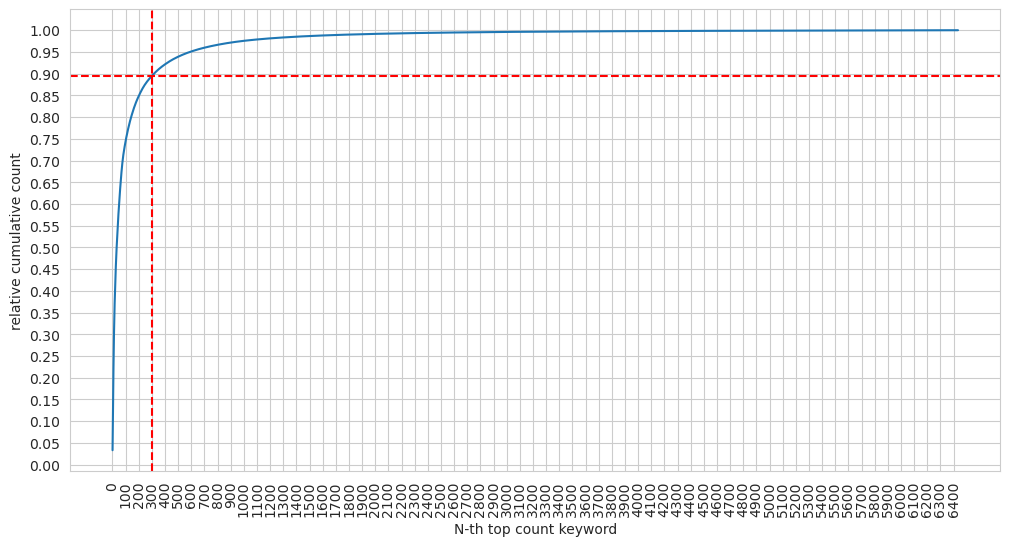

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x=df_medium_long_vc.index, y=df_medium_long_vc['relative cumulative count'], ax=ax)
ax.set_xticks(np.arange(0, len(df_medium_long_vc), 100))
ax.set_xticklabels(np.arange(0, len(df_medium_long_vc), 100), rotation=90)
ax.axvline(x=300, color='red', linestyle='--')
ax.set_yticks(np.arange(0.0, 1.05, 0.05))
ax.axhline(y=df_medium_long_vc.loc[300]['relative cumulative count'], color='red', linestyle='--')
ax.set_xlabel('N-th top count keyword')
plt.show()

Using this elbow method me can decide, that first **300** values will be used, covering almost **90%** of all values.

If we look manually at those 300 values, we will see, that there are some invalid values, that should be deleted:

In [32]:
invalid_values = {'so', 'in', 'de'}
df_medium_long['Medium'] = df_medium_long['Medium'].apply(lambda x: x if x not in invalid_values else np.NaN)

In [33]:
df_medium_long.drop(columns='Medium (string length)', inplace=True)

### Medium Multi-Hot Encoding

Now we will create multi-hot encoding, that can be used later for kNN classification.

In [34]:
df_medium_group_by = df_medium_long.groupby(by='Object ID')['Medium'].apply(set)

In [43]:
features = sorted(df_medium_long_vc.head(300)['Medium'].tolist())
df_medium_multi_hot = pd.DataFrame(0, index=df_objects['Object ID'], columns=features, dtype='uint8')
df_medium_multi_hot.head()

,acrylic,adhered,agate,alabaster,album,albumen,alloy,applied,aquatint,aria,...,white,wire,wood,woodblock,woodcut,wool,wove,woven,wrapped,yellow
Object ID,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
for obj_id, keywords_set in tqdm(df_medium_group_by.items(), total=len(df_medium_group_by)):
    df_medium_multi_hot.loc[obj_id, list(keywords_set)] = 1

  0%|          | 1954/484956 [00:24<1:42:56, 78.21it/s] 


KeyboardInterrupt: 

In [241]:
df_medium_multi_hot.head()

Object ID
1              {gold}
2              {gold}
3              {gold}
4              {gold}
5              {gold}
             ...     
900605    {engraving}
900606      {etching}
900633      {etching}
900717          {nan}
900748      {etching}
Name: Medium, Length: 484956, dtype: object

In [240]:
df_medium_multi_hot

,Object ID,etching,lithograph,silver,print,silk,ink,paper,engraving,commercial,...,bodycolor,aria,design,sago,vitreous,lap,photo,panel,touch,original
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484951,900605,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
484952,900606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
484953,900633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
484954,900717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 7. Dimensions

In [128]:
df_dimensions = pd.read_csv(dataset_path, usecols=['Dimensions'], low_memory=False)

In [65]:
df_dimensions['Dimensions'].unique()

array(['Dimensions unavailable', 'Diam. 11/16 in. (1.7 cm)',
       'Diam. 1/2 in. (1.3 cm)', ...,
       'Plate: 8 3/4 × 5 7/8 in. (22.2 × 15 cm)\r\nSheet: 12 3/16 × 8 3/8 in. (31 × 21.2 cm)',
       '2 pages, 30 unnumbered leaves of plates (some color and folded) : illustrations (some color) ; Height: 11 7/16 in. (29 cm)',
       'Image: 6 5/8 × 11 3/4 in. (16.9 × 29.9 cm)\r\nPlate: 8 15/16 × 13 5/8 in. (22.7 × 34.6 cm)\r\nSheet: 10 13/16 × 15 9/16 in. (27.4 × 39.5 cm)'],
      dtype=object)